In [1]:
R.version.string

[1] "R version 4.4.3 (2025-02-28)"

In [2]:
library(EnrichedHeatmap); library(ComplexHeatmap); library(circlize)
library(GenomicRanges); library(rtracklayer)

Loading required package: grid

Loading required package: ComplexHeatmap

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, va

In [3]:
library(curl); library(xml2); library(openssl)

Using libcurl 8.14.1 with OpenSSL/3.5.4

Linking to: OpenSSL 3.5.4 30 Sep 2025



In [4]:
library(rentrez)

In [5]:
library(ashr)

In [6]:
library(reticulate)
library(tidyverse)
library(here)
library(qs)
library(ggbeeswarm)
library(dplyr)
# Now run:
library(rtracklayer)
library(EnrichedHeatmap)
library(ComplexHeatmap)
library(circlize)
library(grid)
library(GenomeInfoDb)
library(DESeq2)
library(powerjoin)
library(broom)
library(ggplot2)
library(tidyr)
library(tidyverse)
library(devtools)
library(Rsubread)
library(edgeR)
library(biomaRt)
library(ggrepel)
library(ggpubr)
library(purrr)
library(stringr)



Attaching package: ‘reticulate’


The following object is masked from ‘package:rtracklayer’:

    import


── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%() masks IRanges::%within%()
✖ dplyr::collapse()     masks IRanges::collapse()
✖ dplyr::combine()      masks BiocGenerics::combine()
✖ dplyr::desc()         masks IRanges::desc()
✖ tidyr::expand()

In [7]:
1

[1] 1

# read in ISG full list and add ensembl IDs

In [8]:
isg_df <- read.table("isg.txt", 
                 header = FALSE, 
                 sep = "\t", 
                 stringsAsFactors = FALSE)

In [9]:
colnames(isg_df) <- c("GeneName")

In [10]:
# Choose species (here: human); for mouse use "mmusculus_gene_ensembl"
mart <- useEnsembl(biomart = "ensembl", dataset = "hsapiens_gene_ensembl")

In [11]:
genes <- isg_df$GeneName

In [12]:
map_df <- getBM(
  attributes = c("hgnc_symbol","ensembl_gene_id","entrezgene_id","gene_biotype"),
  filters    = "hgnc_symbol",
  values     = genes,
  mart       = mart
)

In [13]:
map_dedup <- map_df |>
  arrange(hgnc_symbol, desc(gene_biotype == "protein_coding")) |>
  distinct(hgnc_symbol, .keep_all = TRUE)

In [14]:
head(map_dedup)

,hgnc_symbol,ensembl_gene_id,entrezgene_id,gene_biotype
,<chr>,<chr>,<int>,<chr>
1,ABLIM3,ENSG00000173210,22885,protein_coding
2,ABTB2,ENSG00000166016,25841,protein_coding
3,ACSL1,ENSG00000151726,2180,protein_coding
4,ADAMDEC1,ENSG00000134028,27299,protein_coding
5,ADAR,ENSG00000160710,103,protein_coding
6,ADM,ENSG00000148926,133,protein_coding


In [15]:
dim(map_dedup)

[1] 324   4

# read in the RenVM cells Steve file and do DGE for upregulated genes extraction

In [125]:
df1 <- read.csv("aligned_counts_ReN VM RNAseq by Laura_original.csv")

In [126]:
dim(df1)

[1] 58742    62

In [28]:
head(df1)

,id,symbol,S1,S2,S3,S4,S5,S6,S7,S8,⋯,S51,S52,S53,S54,S55,S56,S57,S58,S59,S60
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ENSG00000223972,DDX11L1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,ENSG00000227232,WASH7P,0,1,1,0,0,0,0,1,⋯,0,0,2,1,1,2,1,0,1,0
3,ENSG00000278267,MIR6859-1,2,0,1,0,1,1,0,1,⋯,0,1,1,1,2,4,0,2,0,0
4,ENSG00000243485,MIR1302-2HG,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,ENSG00000284332,MIR1302-2,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,ENSG00000237613,FAM138A,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [29]:
tail(df1)

,id,symbol,S1,S2,S3,S4,S5,S6,S7,S8,⋯,S51,S52,S53,S54,S55,S56,S57,S58,S59,S60
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
58737,ENSG00000275063,AC233755.1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
58738,ENSG00000271254,AC240274.1,53,50,45,11,12,29,55,34,⋯,39,40,67,60,78,63,35,54,66,43
58739,ENSG00000275405,RF00003,0,0,0,0,0,0,0,0,⋯,0,0,1,0,0,0,0,0,0,0
58740,ENSG00000275987,RF00003,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
58741,ENSG00000277475,AC213203.2,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
58742,ENSG00000268674,AC213203.1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [127]:
df2 <- df1[,c("id","symbol","S4","S5","S6","S1","S2","S3")]

In [31]:
head(df2)

,id,symbol,S4,S5,S6,S1,S2,S3
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ENSG00000223972,DDX11L1,0,0,0,0,0,0
2,ENSG00000227232,WASH7P,0,0,0,0,1,1
3,ENSG00000278267,MIR6859-1,0,1,1,2,0,1
4,ENSG00000243485,MIR1302-2HG,0,0,0,0,0,0
5,ENSG00000284332,MIR1302-2,0,0,0,0,0,0
6,ENSG00000237613,FAM138A,0,0,0,0,0,0


In [128]:
# Keep an annotation lookup so we can reattach symbols later
gene_annot <- df2 %>%
  dplyr::select(id, symbol) %>%
  distinct()

In [129]:
dim(gene_annot)

[1] 58736     2

In [130]:
dim(df2)

[1] 58742     8

In [131]:
# Build counts matrix (rownames = Ensembl IDs)
count_mat <- df2 %>%
  dplyr::select(-symbol) %>%
  distinct(id, .keep_all = TRUE) %>%
  column_to_rownames("id") %>%
  as.matrix()

In [132]:
storage.mode(count_mat) <- "integer"

Warning message in storage.mode(count_mat) <- "integer":
“NAs introduced by coercion”


In [133]:
# ---- 1) Sample metadata ----
coldata <- tibble(
  sample    = c("S4","S5","S6","S1","S2","S3"),
  condition = factor(c("case","case","case","control","control","control"),
                     levels = c("control","case"))
)

In [134]:
count_mat <- count_mat[, coldata$sample]

In [135]:
head(count_mat)

,S4,S5,S6,S1,S2,S3
ENSG00000223972,0,0,0,0,0,0
ENSG00000227232,0,0,0,0,1,1
ENSG00000278267,0,1,1,2,0,1
ENSG00000243485,0,0,0,0,0,0
ENSG00000284332,0,0,0,0,0,0
ENSG00000237613,0,0,0,0,0,0


In [136]:
# choose the exact sample columns you want
samples <- c("S4","S5","S6","S1","S2","S3")

# 1a) Inspect NA locations quickly
df2 %>% 
  dplyr::select(id, all_of(samples)) %>%
  summarise(across(all_of(samples), ~sum(is.na(.)))) 
# if any column shows >0, you have NAs

S4,S5,S6,S1,S2,S3
<int>,<int>,<int>,<int>,<int>,<int>
0,0,0,0,0,0


In [44]:
dim(count_mat)

[1] 58736     6

In [137]:
# If those NAs truly mean "absent", set to 0; otherwise inspect upstream
count_mat[is.na(count_mat)] <- 0


In [138]:
storage.mode(count_mat) <- "integer"

In [139]:
dds <- DESeqDataSetFromMatrix(countData = count_mat,
                              colData   = as.data.frame(coldata),
                              design    = ~ condition)

In [140]:
dim(dds)

[1] 58736     6

In [141]:
zero_rows <- rowSums(count_mat == 0) == ncol(count_mat)
which(zero_rows)

ENSG00000223972 ENSG00000243485 ENSG00000284332 ENSG00000237613 ENSG00000268020 
              1               4               5               6               7 
ENSG00000186092 ENSG00000238009 ENSG00000239945 ENSG00000233750 ENSG00000269981 
              9              10              11              12              14 
ENSG00000239906 ENSG00000241860 ENSG00000222623 ENSG00000241599 ENSG00000279928 
             15              16              17              18              19 
ENSG00000273874 ENSG00000236601 ENSG00000269732 ENSG00000284733 ENSG00000233653 
             21              24              26              27              28 
ENSG00000278757 ENSG00000235146 ENSG00000278791 ENSG00000240409 ENSG00000268663 
             30              32              36              38              41 
ENSG00000284662 ENSG00000229376 ENSG00000223181 ENSG00000229905 ENSG00000285268 
             42              43              45              46              48 
ENSG00000230368 ENSG00000234711 ENSG00000283040 ENSG00000241180 ENSG00000231702 
             53              54              55              58              68 
ENSG00000242590 ENSG00000285812 ENSG00000207730 ENSG00000207607 ENSG00000260179 
             71              76              78              79              89 
ENSG00000278073 ENSG00000283712 ENSG00000284372 ENSG00000223663 ENSG00000264293 
             94              97             102             105             109 
ENSG00000225905 ENSG00000205116 ENSG00000274481 ENSG00000215914 ENSG00000226969 
            112             113             123             132             145 
ENSG00000271806 ENSG00000234396 ENSG00000224387 ENSG00000229393 ENSG00000272449 
            147             150             159             160             163 
ENSG00000238164 ENSG00000225931 ENSG00000237058 ENSG00000215912 ENSG00000285945 
            164             166             170             171             172 
ENSG00000233234 ENSG00000231630 ENSG00000284745 ENSG00000169717 ENSG00000283572 
            174             175             176             177             180 
ENSG00000226286 ENSG00000272088 ENSG00000207776 ENSG00000227589 ENSG00000276189 
            181             185             187             192             195 
ENSG00000272153 ENSG00000233304 ENSG00000226374 ENSG00000284668 ENSG00000284703 
            200             205             206             207             208 
ENSG00000229280 ENSG00000235054 ENSG00000284694 ENSG00000227169 ENSG00000232596 
            209             210             211             212             213 
ENSG00000284739 ENSG00000284674 ENSG00000231510 ENSG00000284616 ENSG00000284692 
            215             216             217             218             219 
ENSG00000284666 ENSG00000260972 ENSG00000283356 ENSG00000236948 ENSG00000264341 
            220             221             222             223             224 
ENSG00000264101 ENSG00000285629 ENSG00000225077 ENSG00000173673 ENSG00000265392 
            225             229             234             235             241 
ENSG00000231868 ENSG00000253022 ENSG00000229519 ENSG00000228750 ENSG00000284744 
            242             246             247             254             255 
ENSG00000227950 ENSG00000237365 ENSG00000207056 ENSG00000237728 ENSG00000225126 
            258             259             260             262             263 
ENSG00000270171 ENSG00000270035 ENSG00000269978 ENSG00000236266 ENSG00000270330 
            264             265             266             270             273 
ENSG00000200344 ENSG00000284716 ENSG00000229305 ENSG00000227634 ENSG00000200975 
            275             277             281             282             283 
ENSG00000233645 ENSG00000251977 ENSG00000252254 ENSG00000221083 ENSG00000270282 
            284             285             287             290             291 
ENSG00000224315 ENSG00000222511 ENSG00000226545 ENSG00000228423 ENSG00000229716 
            293             294

In [59]:
length(rownames(count_mat)[zero_rows])

[1] 32078

In [60]:
sum(zero_rows)

[1] 32078

In [61]:
head(count_mat[!zero_rows, ])

,S4,S5,S6,S1,S2,S3
ENSG00000227232,0,0,0,0,1,1
ENSG00000278267,0,1,1,2,0,1
ENSG00000240361,0,0,0,1,0,0
ENSG00000268903,0,1,0,0,0,0
ENSG00000279457,4,3,4,12,11,13
ENSG00000228463,1,1,0,5,4,3


In [62]:
count_mat[zero_rows, ]

,S4,S5,S6,S1,S2,S3
ENSG00000223972,0,0,0,0,0,0
ENSG00000243485,0,0,0,0,0,0
ENSG00000284332,0,0,0,0,0,0
ENSG00000237613,0,0,0,0,0,0
ENSG00000268020,0,0,0,0,0,0
ENSG00000186092,0,0,0,0,0,0
ENSG00000238009,0,0,0,0,0,0
ENSG00000239945,0,0,0,0,0,0
ENSG00000233750,0,0,0,0,0,0
ENSG00000269981,0,0,0,0,0,0


In [142]:
# filter low counts
keep <- rowSums(counts(dds) >= 1) >= 1
dds <- dds[keep, ]

In [143]:
dim(dds)

[1] 26658     6

In [144]:
dds <- DESeq(dds)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [145]:
# results + shrinkage
library(apeglm)
res  <- results(dds, contrast = c("condition","case","control"), alpha = 0.05)
resL <- lfcShrink(dds, coef = "condition_case_vs_control", type = "apeglm")

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



In [146]:
# ---- 4) Merge with symbols & tidy tables ----
# 'res_shr' from lfcShrink(); 'gene_annot' has id,symbol
res_tbl <- as.data.frame(resL) %>%
  rownames_to_column("id") %>%
  left_join(gene_annot %>% distinct(id, symbol), by = "id") %>%
  mutate(symbol = if_else(is.na(symbol) | symbol == "", id, symbol),
         neg_log10_p = -log10(pvalue),
         abs_lfc     = abs(log2FoldChange)) %>%
  relocate(symbol, .after = id) %>%
  arrange(padj, desc(abs_lfc))

In [147]:
dim(res_tbl); head(res_tbl)

[1] 26658     9

,id,symbol,baseMean,log2FoldChange,lfcSE,pvalue,padj,neg_log10_p,abs_lfc
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000169248,CXCL11,12235.374,8.278299,0.1052435,0,0,Inf,8.278299
2,ENSG00000163131,CTSS,2751.893,7.809828,0.1693091,0,0,Inf,7.809828
3,ENSG00000169245,CXCL10,46913.518,7.025947,0.1731275,0,0,Inf,7.025947
4,ENSG00000138755,CXCL9,1824.580,6.769503,0.1549649,0,0,Inf,6.769503
5,ENSG00000125730,C3,2383.570,6.683664,0.1341191,0,0,Inf,6.683664
6,ENSG00000121858,TNFSF10,3436.708,6.515817,0.1121936,0,0,Inf,6.515817


In [148]:
# DEG subsets (edit cutoffs as needed)
alpha   <- 0.05
lfc_thr <- 0
deg_up  <- res_tbl %>% filter(!is.na(padj), padj <= alpha,  log2FoldChange >=  lfc_thr)
deg_dn  <- res_tbl %>% filter(!is.na(padj), padj <= alpha,  log2FoldChange <= -lfc_thr)

In [149]:
dim(deg_up); head(deg_up)

[1] 5019    9

,id,symbol,baseMean,log2FoldChange,lfcSE,pvalue,padj,neg_log10_p,abs_lfc
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000169248,CXCL11,12235.374,8.278299,0.1052435,0,0,Inf,8.278299
2,ENSG00000163131,CTSS,2751.893,7.809828,0.1693091,0,0,Inf,7.809828
3,ENSG00000169245,CXCL10,46913.518,7.025947,0.1731275,0,0,Inf,7.025947
4,ENSG00000138755,CXCL9,1824.580,6.769503,0.1549649,0,0,Inf,6.769503
5,ENSG00000125730,C3,2383.570,6.683664,0.1341191,0,0,Inf,6.683664
6,ENSG00000121858,TNFSF10,3436.708,6.515817,0.1121936,0,0,Inf,6.515817


In [71]:
dim(deg_dn); head(deg_dn)

[1] 4598    9

,id,symbol,baseMean,log2FoldChange,lfcSE,pvalue,padj,neg_log10_p,abs_lfc
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000182175,RGMA,1112.227,-5.149096,0.13561261,0,0,Inf,5.149096
2,ENSG00000131095,GFAP,34130.267,-4.901503,0.07420366,0,0,Inf,4.901503
3,ENSG00000132470,ITGB4,1562.708,-4.613769,0.10644086,0,0,Inf,4.613769
4,ENSG00000164434,FABP7,3784.349,-4.176952,0.09296813,0,0,Inf,4.176952
5,ENSG00000167552,TUBA1A,9699.286,-4.094455,0.06188925,0,0,Inf,4.094455
6,ENSG00000106278,PTPRZ1,6847.362,-3.937527,0.08989990,0,0,Inf,3.937527


In [150]:
# Optional: add a quick rank column
res_tbl <- res_tbl %>%
  mutate(rank_by_padj = rank(padj, ties.method = "first"))

In [151]:
# ---- 5) Normalized counts & VST for plots ----
norm_counts <- counts(dds, normalized = TRUE) %>%
  as.data.frame() %>%
  rownames_to_column("id") %>%
  left_join(gene_annot %>% distinct(id, symbol), by = "id") %>%
  mutate(symbol = if_else(is.na(symbol) | symbol == "", id, symbol)) %>%
  relocate(symbol, .after = id)

In [74]:
vst_dt <- vst(dds, blind = TRUE)   # DESeqTransform object

# ---- 6) Diagnostics ----
# PCA (by condition)
pca_df <- plotPCA(vst_dt, intgroup = "condition", returnData = TRUE)
percentVar <- round(100 * attr(pca_df, "percentVar"))

using ntop=500 top features by variance



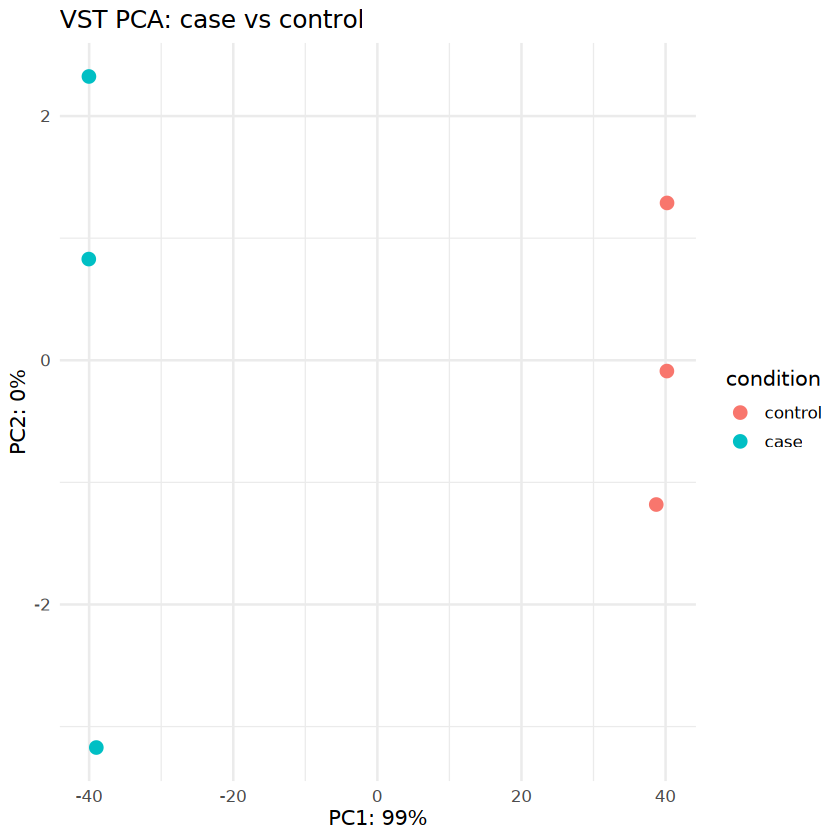

In [75]:
ggplot(pca_df, aes(PC1, PC2, color = condition)) +
  geom_point(size = 3) +
  xlab(paste0("PC1: ", percentVar[1], "%")) +
  ylab(paste0("PC2: ", percentVar[2], "%")) +
  ggtitle("VST PCA: case vs control") +
  theme_minimal(base_size = 12)

In [76]:
# Volcano (safe y-axis; optional labels for top hits)
volc_df <- res_tbl %>%
  mutate(sig = !is.na(padj) & padj <= alpha & abs_lfc >= lfc_thr,
         # add tiny epsilon so -log10 is finite when pvalue==0
         y  = -log10(pvalue + 1e-300))

Warning message:
“ggrepel: 38 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


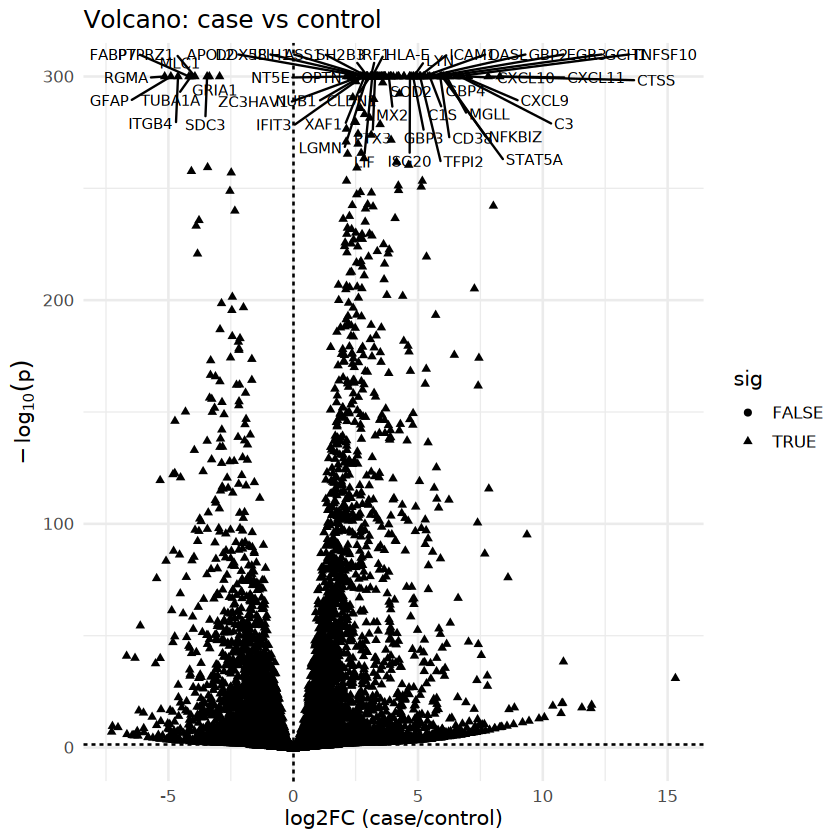

In [77]:
# choose a few labels (top 10 by padj among significant)
label_df <- volc_df %>% filter(sig) %>% slice_min(padj, n = 10)

ggplot(volc_df, aes(x = log2FoldChange, y = y)) +
  geom_point(aes(shape = sig)) +
  geom_vline(xintercept = c(-lfc_thr, lfc_thr), linetype = 2) +
  geom_hline(yintercept = -log10(alpha), linetype = 2) +
  labs(title = "Volcano: case vs control",
       x = "log2FC (case/control)",
       y = expression(-log[10](p))) +
  theme_minimal(base_size = 12) +
  # Label only a few top significant genes; silently skip if ggrepel is absent
  {if (requireNamespace("ggrepel", quietly = TRUE))
      ggrepel::geom_text_repel(data = label_df,
                               aes(label = symbol),
                               size = 3, max.overlaps = 100)
    else ggplot2::geom_text(data = label_df,
                            aes(label = symbol), size = 3, vjust = -0.6)}

In [78]:
summary(deg_up)

      id               symbol             baseMean        log2FoldChange   
 Length:5019        Length:5019        Min.   :    1.45   Min.   : 0.1438  
 Class :character   Class :character   1st Qu.:   60.09   1st Qu.: 0.5979  
 Mode  :character   Mode  :character   Median :  270.73   Median : 1.1181  
                                       Mean   :  695.34   Mean   : 1.6313  
                                       3rd Qu.:  663.42   3rd Qu.: 2.0909  
                                       Max.   :50931.86   Max.   :15.3117  
     lfcSE             pvalue               padj            neg_log10_p    
 Min.   :0.05260   Min.   :0.000e+00   Min.   :0.000e+00   Min.   : 1.608  
 1st Qu.:0.09687   1st Qu.:0.000e+00   1st Qu.:0.000e+00   1st Qu.: 3.307  
 Median :0.13544   Median :1.200e-08   Median :5.000e-08   Median : 7.916  
 Mean   :0.34194   Mean   :2.003e-03   Mean   :4.362e-03   Mean   :   Inf  
 3rd Qu.:0.29171   3rd Qu.:4.934e-04   3rd Qu.:1.354e-03   3rd Qu.:24.840  
 Max.   :3.4

In [79]:
head(isg_df)

,GeneName
,<chr>
1,IFIH1
2,CXCL9
3,CREB3L3
4,GTPBP1
5,DDX58
6,G6PC


In [152]:
new_list1 <- intersect(isg_df$GeneName, deg_up$symbol)

In [153]:
length(new_list1)

[1] 239

In [154]:
dim(deg_up[deg_up$symbol %in% new_list1,])

[1] 239   9

In [155]:
head(deg_up[deg_up$symbol %in% new_list1,])

,id,symbol,baseMean,log2FoldChange,lfcSE,pvalue,padj,neg_log10_p,abs_lfc
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000169248,CXCL11,12235.374,8.278299,0.1052435,0,0,Inf,8.278299
3,ENSG00000169245,CXCL10,46913.518,7.025947,0.1731275,0,0,Inf,7.025947
4,ENSG00000138755,CXCL9,1824.580,6.769503,0.1549649,0,0,Inf,6.769503
6,ENSG00000121858,TNFSF10,3436.708,6.515817,0.1121936,0,0,Inf,6.515817
7,ENSG00000162654,GBP4,1500.400,6.267963,0.1514558,0,0,Inf,6.267963
11,ENSG00000131979,GCH1,1550.060,5.935457,0.1288661,0,0,Inf,5.935457


In [156]:
new_list1

[1] "IFIH1"     "CXCL9"     "GTPBP1"    "DDX58"     "VAMP5"     "IRF1"     
  [7] "B2M"       "SPTLC2"    "IRF7"      "OASL"      "IFI44L"    "CCL2"     
 [13] "PDGFRL"    "MT1X"      "SOCS1"     "CCL4"      "HSH2D"     "GEM"      
 [19] "XAF1"      "HLA-G"     "SLFN5"     "IFI35"     "APOL2"     "USP18"    
 [25] "APOL1"     "FBXO6"     "JUNB"      "SLC25A28"  "HLA-E"     "MAB21L2"  
 [31] "C4orf33"   "WARS"      "IRF2"      "CCL5"      "TNFSF10"   "VEGFC"    
 [37] "IFITM2"    "TRIM21"    "TNFAIP6"   "IFIT1"     "PI4K2B"    "HK2"      
 [43] "IFITM3"    "MYD88"     "CCL8"      "DYNLT1"    "SP110"     "IFIT5"    
 [49] "ETV7"      "DTX3L"     "MT1H"      "NAPA"      "MAFB"      "NRN1"     
 [55] "CXCL10"    "C15orf48"  "NOD2"      "MT1G"      "EIF2AK2"   "DDIT4"    
 [61] "PMM2"      "HESX1"     "LAP3"      "LY6E"      "MT1F"      "ABTB2"    
 [67] "GTPBP2"    "TLR3"      "GMPR"      "BATF2"     "ISG15"     "TNFRSF10A"
 [73] "GCH1"      "GBP2"      "SERPINE1"  "DCP1A"     "SMAD3"     "EPSTI1"   
 [79] "MT1M"      "MAP3K14"   "AIM2"      "NFIL3"     "BTN3A3"    "BCL2L14"  
 [85] "PNRC1"     "KIAA0040"  "ENPP1"     "PML"       "PDK1"      "LGALS9"   
 [91] "CASP7"     "LGALS3"    "PARP12"    "HES4"      "OAS2"      "IFNGR1"   
 [97] "IFI44"     "TRIM5"     "SERPING1"  "MAFF"      "LGMN"      "UBE2L6"   
[103] "IMPA2"     "CEBPD"     "CYP1B1"    "SECTM1"    "PMAIP1"    "CXCL11"   
[109] "TMEM51"    "TNFSF13B"  "EXT1"      "ZBP1"      "HPSE"      "TYMP"     
[115] "BLVRA"     "MAX"       "TRIM14"    "FUT4"      "SCARB2"    "CCND3"    
[121] "TRIM38"    "MTHFD2L"   "CCR1"      "TBX3"      "SLC15A3"   "CD74"     
[127] "ISG20"     "MX1"       "DHX58"     "CHMP5"     "BCL3"      "LAMP3"    
[133] "EHD4"      "TDRD7"     "BAG1"      "DUSP5"     "HLA-C"     "AQP9"     
[139] "IL6ST"     "GBP4"      "GLRX"      "PHF11"     "MCOLN2"    "TLK2"     
[145] "IFI6"      "PPM1K"     "NCOA3"     "ATP10D"    "GBP5"      "SERPINB9" 
[151] "PTMA"      "BST2"      "AMPH"      "RARRES3"   "CX3CL1"    "STARD5"   
[157] "ADM"       "ETV6"      "IL1RN"     "FKBP5"     "UNC93B1"   "IFI27"    
[163] "GBP1"      "MCL1"      "SAMD4A"    "CLEC2B"    "IFIT3"     "IFI16"    
[169] "HLA-F"     "FNDC3B"    "NPAS2"     "LMO2"      "RNF19B"    "HEG1"     
[175] "PRKD2"     "CCNA1"     "PSMB9"     "LIPA"      "C1S"       "OPTN"     
[181] "NMI"       "ADAR"      "IDO1"      "DDX3X"     "TNFAIP3"   "TIMP1"    
[187] "IFIT2"     "JAK2"      "STAT2"     "ATF3"      "PSMB8"     "HERC6"    
[193] "MICB"      "GCA"       "GJA4"      "RBCK1"     "PIM3"      "GBP3"     
[199] "OGFR"      "SAMHD1"    "IL15"      "ELF1"      "PNPT1"     "RIPK2"    
[205] "SLC25A30"  "IL15RA"    "TRAFD1"    "CD38"      "CD274"     "SPSB1"    
[211] "PLSCR1"    "TRIM25"    "STAT1"     "MASTL"     "TMEM140"   "ZNF385B"  
[217] "TXNIP"     "RTP4"      "B4GALT5"   "TCF7L2"    "ACSL1"     "TAP1"     
[223] "RBM25"     "PLEKHA4"   "RSAD2"     "APOL6"     "RAB27A"    "IFITM1"   
[229] "MX2"       "DDX60"     "STAT3"     "RASGEF1B"  "PABPC4"    "OAS1"     
[235] "FLT1"      "OAS3"      "N4BP1"     "APOL3"     "BLZF1"

In [157]:
write_lines(new_list1,"RenVM_cells_ISG_upregulated_genes_list.txt")

In [158]:
renvm_ISG_up <- new_list1

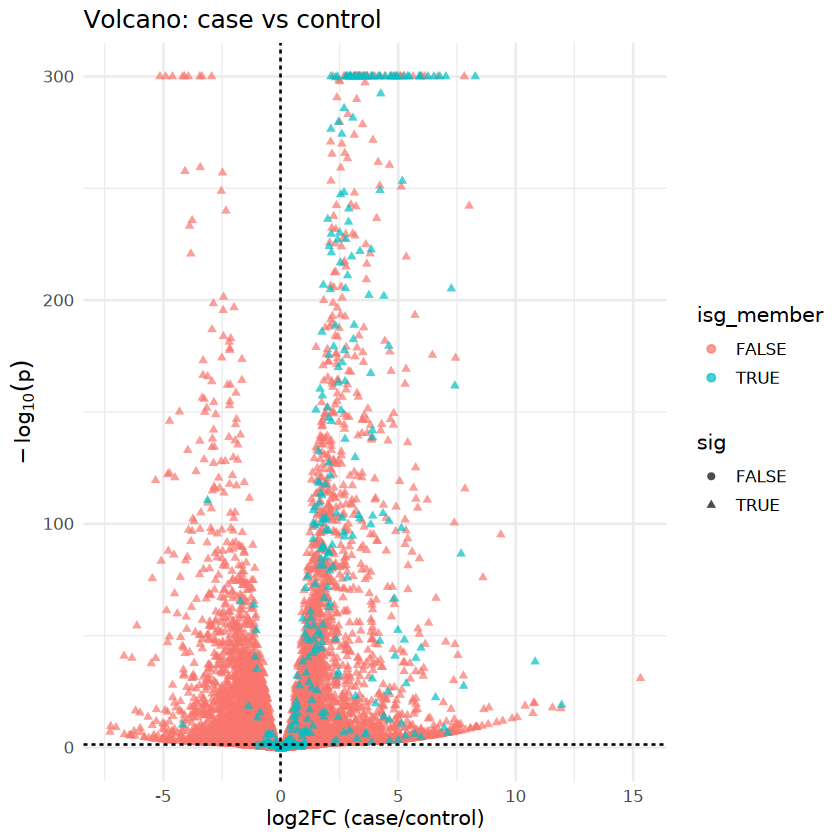

In [84]:
# choose a few labels (top 10 by padj among significant)
label_df <- volc_df %>% filter(sig) %>% slice_min(padj, n = 10)

volc_df %>%
  mutate(isg_member = symbol %in% isg_df$GeneName ) %>%
  arrange(isg_member) %>%
  ggplot(aes(x = log2FoldChange, y = y)) +
  geom_point(aes(shape = sig, color = isg_member), alpha = .7) +
  geom_vline(xintercept = c(-lfc_thr, lfc_thr), linetype = 2) +
  geom_hline(yintercept = -log10(alpha), linetype = 2) +
  labs(title = "Volcano: case vs control",
       x = "log2FC (case/control)",
       y = expression(-log[10](p))) +
  theme_minimal(base_size = 12)

## DGE analysis of the TEs

In [16]:
library(rentrez)

In [17]:
library(lmerTest)

Loading required package: lme4

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


The following object is masked from ‘package:S4Vectors’:

    expand



Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step




In [18]:
sprint_all <- read_csv(
  "../../STAR_data/sprint_repeat_overlaps.csv",
  col_names = TRUE)

Rows: 22057717 Columns: 13
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (7): chrom, run_id, type, strand, rep_name, class_family, repeat_strand
dbl (6): position, supporting_reads, ad, dp, repeat_start, repeat_end

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [19]:
liu_repeat_counts <- qread("liu_repeat_counts_raw-fraction_AND_secondary_noMETA.qs")

In [20]:
rm_raw <- read_csv(
  "repeatmasker_raw.csv",
  col_names = TRUE)

Rows: 5448004 Columns: 16
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (8): chromosome, left, strand, rep_name, class_family, rep_start, rep_le...
dbl (8): sw_score, perc_div, perc_del, perc_ins, start, end, rep_end, id

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [21]:
liu_meta <- read_csv(
  "liu_sample_meta.csv",
  col_names = TRUE)

Rows: 14 Columns: 34
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (29): Run, Assay Type, BioProject, BioSample, Cell_type, Center Name, C...
dbl   (4): AvgSpotLen, Bases, Bytes, size_factor
dttm  (1): ReleaseDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [22]:
repeat_whitelist <- rm_raw %>%
  distinct(class_family) %>%
  filter(
    !str_detect(class_family, coll("?")),
    !str_detect(class_family, coll("Jockey")),
    !str_detect(class_family, coll("Tx1")),
    !str_detect(class_family, coll("Dong")),
    !str_detect(class_family, coll("Penelope")),
    !str_detect(class_family, coll("5S-Deu-L2")),
    !str_detect(class_family, coll("tRNA-Deu")),
    !str_detect(class_family, coll("tRNA-RTE")),
    !str_detect(class_family, coll("RTE-BovB")),
    !str_detect(class_family, coll("Gypsy")),
    !str_detect(class_family, coll("RTE-X")),
    !str_detect(class_family, coll("CR1")),
    str_starts(class_family, coll("LTR")) |
      str_starts(class_family, coll("SINE")) |
      str_starts(class_family, coll("LINE")) |
      str_starts(class_family, coll("Retroposon/SVA")) #| 
      #str_starts(class_family, coll("Simple_repeat"))
  )


In [23]:
sprint_all_agg <- sprint_all %>% 
  filter(type %in% c("AG", "TC")) %>% 
  mutate(
    nedited  = ad,
    unedited = dp - ad,             # true unedited depth
    sample_id = run_id
  ) %>% 
  group_by(class_family, sample_id) %>% 
  summarise(
    supporting_reads = sum(supporting_reads),
    nedited  = sum(nedited),
    unedited = sum(unedited),
    total    = nedited + unedited,  # now equals Σdp
    .groups  = "drop"
  )

In [24]:
library(dplyr)
library(purrr)

In [25]:
class(sprint_all)

[1] "spec_tbl_df" "tbl_df"      "tbl"         "data.frame"

In [26]:
head(sprint_all)

chrom,position,run_id,type,supporting_reads,strand,ad,dp,rep_name,class_family,repeat_start,repeat_end,repeat_strand
<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,109864,SRR8571937,AG,1,+,1,69,FAM,SINE/Alu,109836,110009,C
1,109864,SRR8571939,AG,1,+,3,193,FAM,SINE/Alu,109836,110009,C
1,109864,SRR8571940,AG,1,+,2,139,FAM,SINE/Alu,109836,110009,C
1,109864,SRR8571950,AG,5,+,7,117,FAM,SINE/Alu,109836,110009,C
1,109872,SRR8571937,AG,1,+,1,75,FAM,SINE/Alu,109836,110009,C
1,109872,SRR8571939,AG,1,+,1,216,FAM,SINE/Alu,109836,110009,C


In [25]:
#sprint_all_counts <- count(sprint_all, `class_family`)
sprint_all_counts <- dplyr::count(
  sprint_all, class_family, sort = TRUE, name = "n"
)

In [26]:
abs_test_data <- sprint_all_agg %>%
  semi_join(
    repeat_whitelist,
    by = "class_family"
  ) %>%
  bind_rows(
    group_by(
      .,
      sample_id
    ) %>%
    summarise(
      across(c(nedited, unedited, total, supporting_reads), sum),
      .groups = "drop"
    ) %>%
    mutate(
      class_family = "all"
    )
  ) %>%
  power_inner_join(
    liu_meta %>%
      dplyr::select(Run, patient_sample_id, tdp_43_status, size_factor),
    by = c("sample_id" = "Run"),
    check = check_specs(
      unmatched_keys_left = "warn",
      duplicate_keys_right = "warn"
    )
  ) %>%
  mutate(
    across(
      c(nedited, unedited, total, supporting_reads),
      .fns = list(
        adjusted = \(x) x / size_factor
      )
    )
  )

abs_test_data_long <- abs_test_data %>%
  dplyr::select(class_family, nedited, unedited, total, supporting_reads, patient_sample_id, tdp_43_status, ends_with("adjusted")) %>%
  pivot_longer(
    cols = -c(class_family, patient_sample_id, tdp_43_status),
    names_to = "type",
    values_to = "value"
  )



Warning message:
“Keys in the left table have unmatched combinations:
# A tibble: 2 × 1
  sample_id 
  <chr>     
1 SRR8571943
2 SRR8571946”


In [27]:
count_type_human_readable <- c(
  nedited_adjusted = "Edited reads",
  unedited_adjusted = "Unedited reads",
  total_adjusted = "Total reads",
  supporting_reads_adjusted = "Score adjusted"
)

In [28]:
abs_test_paired_raw <- abs_test_data_long %>%
  semi_join(
    repeat_whitelist,
    by = "class_family"
  ) %>%
  mutate(
    across(value, log10)
  ) %>%
  pivot_wider(
    names_from = `tdp_43_status`,
    values_from = -c(`tdp_43_status`, class_family, patient_sample_id, type)
  ) %>%
  mutate(
    difference = `TDP-43 negative` - `TDP-43 positive`
  ) %>%
  group_by(
    class_family, type
  ) %>%
  summarise(
    res = list(
      possibly(lm)(
        difference ~ 1,
        data = pick(everything())
      )
    ),
    .groups = "drop"
  )

In [29]:
abs_test_paired_res <- abs_test_paired_raw %>%
  mutate(
    across(res, \(x) map(x, tidy))
  ) %>%
  unnest(res) %>%
  group_by(
    type
  ) %>%
  mutate(
    padj = p.adjust(p.value, method = "BH")
  ) %>%
  ungroup()

In [30]:
abs_test_random_raw <- abs_test_data_long %>%
  crossing(
    trans = c("log10", "linear")
  ) %>%
  mutate(
    value = if_else(trans == "log10", log10(value), value)
  ) %>%
  group_by(
    type, `class_family`, trans
  ) %>%
  summarise(
    res = list(
      possibly(lmer)(
        value ~ tdp_43_status + (1 | patient_sample_id),
        data = cur_data()
      )
    ),
    .groups = "drop"
  )

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

Warning message:
“There were 29 warnings in `summarise()`.
The first warning was:
ℹ In argument: `res = list(...)`.
ℹ In group 1: `type = "nedited"`, `class_family = "LINE/L1"`, `trans = "linear"`.
Caused by warning:
! `cur_data()` was deprecated in dplyr 1.1.0.
ℹ Please use `pick()` instead.
ℹ Run `dplyr::last_dplyr_warnings()` to see the 28 remaining warnings

In [31]:
library(broom)

In [32]:
library(broom.mixed)

In [33]:
library(lmerTest)

In [34]:
abs_test_res <- abs_test_random_raw %>%
  mutate(
    across(res, \(x) map(x, tidy))
  ) %>%
  unnest(res)

In [35]:
patient_id_color_mapping <- liu_meta %>%
  filter(
    tdp_43_status == "TDP-43 positive"
  ) %>%
  distinct(patient_sample_id) %>%
  arrange() %>%
  pull(patient_sample_id) %>% {
    set_names(
      paletteer::paletteer_d("colorblindr::OkabeIto", length(.)),
      .
    )
  }

In [36]:
1

[1] 1

In [115]:
ps <- abs_test_data_long %>%
  filter(type %in% c("nedited_adjusted", "unedited_adjusted", "total_adjusted", "supporting_reads_adjusted")) %>%
  semi_join(
    repeat_whitelist,
    by = "class_family"
  ) %>%
  group_by(
    type
  ) %>%
  summarize(
    p = list({
      cur_type <- cur_group()$type
      ggplot(
        pick(everything()),
        aes(
          tdp_43_status,
          value,
          color = patient_sample_id
        )
      ) +
      geom_line(
        aes(group = patient_sample_id)
      ) +
      geom_quasirandom(width = .1) +
      scale_color_manual(
        values = patient_id_color_mapping,
        guide = "none"
      ) +
      ggnewscale::new_scale_color() +
      geom_text(
        aes(label = signif(padj, 2), color = padj < 0.05),
        x = -Inf, y = Inf,
        hjust = 0, vjust = 1,
        data = filter(
          abs_test_paired_res,
          type == cur_type
        ),
        inherit.aes = FALSE
      ) +
      scale_color_manual(
        values = c(`TRUE` = "red", `FALSE` = "black"),
        guide = "none"
      ) +
      scale_y_log10(
        expand = expansion(mult = c(.1, .2))
      ) +
      coord_cartesian(
        clip = "off"
      ) +
      ggh4x::facet_wrap2(~class_family, scales = "free_y", axes = "y") +
      theme(
        axis.text.x = element_text(angle = 45, hjust = 1)
      ) +
      labs(
        x = NULL,
        y = count_type_human_readable[cur_type],
        title = count_type_human_readable[cur_type]
      )
    })
  )

In [37]:
repeat_counts_mat <- liu_repeat_counts[["counts"]] %>%
  magrittr::set_colnames(
    str_remove(colnames(.), fixed(".sorted.bam"))
  ) %>% {
    .[, liu_meta$Run]
  }

In [38]:
de_meta <- liu_meta %>%
  dplyr::select(
    Run, patient_sample_id, tdp_43_status
  )

In [39]:
repeat_counts_int <- round(repeat_counts_mat)

In [40]:
de <- DESeqDataSetFromMatrix(
  repeat_counts_int,
  de_meta,
  design = ~ tdp_43_status + patient_sample_id
)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [41]:
liu_salmon <- qread("gse_126542_salmon_tximport.qs")

In [42]:
liu_meta_raw <- read_csv("GSE126542.csv")

Rows: 16 Columns: 29
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (25): Run, Assay Type, BioProject, BioSample, Cell_type, Center Name, C...
dbl   (3): AvgSpotLen, Bases, Bytes
dttm  (1): ReleaseDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [43]:
liu_meta_filtered <- liu_meta_raw %>%
  filter(Run %in% colnames(liu_salmon$abundance)) %>%
  arrange(match(Run, colnames(liu_salmon$abundance)))

In [44]:
library(xml2)

In [45]:
sra_search <- entrez_search(db = "sra", term = "PRJNA522295")

In [46]:
sra_runinfo <- entrez_fetch(db = "sra", id = sra_search$ids, rettype = "xml") %>%
  read_xml()

In [47]:
sra_meta <- map(
  set_names(c("accession", "sample_name", "sample_title")),
  \(x) xml_attr(
    xml_find_all(sra_runinfo, "//Member"),
    x
  )
) %>%
  as_tibble() %>%
  distinct() %>%
  mutate(
    patient_sample_id = str_extract(sample_title, "S\\d+"),
    tdp_43_status = str_extract(sample_title, "/(TDP-43 (?:negative|positive)) ", group = 1)
  )

In [48]:
liu_meta <- liu_meta_raw %>%
  power_inner_join(
    sra_meta,
    by = c("Sample Name" = "sample_name"),
    check = check_specs(
      unmatched_keys_left = "warn",
      duplicate_keys_right = "warn",
      duplicate_keys_left = "warn"
    )
  )

In [49]:
liu_meta_fixed <- liu_meta %>%
  filter(Run %in% colnames(liu_salmon$counts)) %>%
  arrange(match(Run, colnames(liu_salmon$counts))) %>%
  column_to_rownames("Run")

In [50]:
liu_de <- DESeq2::DESeqDataSetFromTximport(
  liu_salmon,
  liu_meta_fixed,
  design = ~1
) %>%
  DESeq2::estimateSizeFactors()

using counts and average transcript lengths from tximport

using 'avgTxLength' from assays(dds), correcting for library size



In [51]:
liu_size_factors <- liu_de %>%
  DESeq2::normalizationFactors() %>%
  apply(2, \(x) exp(mean(log(x))))

In [52]:
liu_meta_sf <- liu_meta %>%
  power_inner_join(
    enframe(
      liu_size_factors,
      name = "Run",
      value = "size_factor"
    ),
    by = "Run",
    check = check_specs(
      unmatched_keys_left = "warn",
      duplicate_keys_right = "warn",
      duplicate_keys_left = "warn",
      unmatched_keys_right = "warn"
    )
  )

Warning message:
“Keys in the left table have unmatched combinations:
# A tibble: 2 × 1
  Run       
  <chr>     
1 SRR8571943
2 SRR8571946”


In [53]:
liu_meta_filtered <- liu_meta %>%
  filter(Run %in% names(liu_size_factors))

In [54]:
liu_meta_sf <- liu_meta_filtered %>%
  power_inner_join(
    enframe(liu_size_factors, name = "Run", value = "size_factor"),
    by = "Run"
  )

In [72]:
sizeFactors(de) <- liu_size_factors

ERROR: Error: unable to find an inherited method for function ‘sizeFactors<-’ for signature ‘object = "function", value = "numeric"’


In [199]:
liu_size_factors

SRR8571937 SRR8571938 SRR8571939 SRR8571940 SRR8571941 SRR8571942 SRR8571944 
 0.8178802  0.8664618  1.3345046  0.9927959  1.0332799  0.9303200  1.3515475 
SRR8571945 SRR8571947 SRR8571948 SRR8571949 SRR8571950 SRR8571951 SRR8571952 
 1.1449636  1.0487050  1.1612927  1.0414088  1.0252426  0.7731989  0.7121530

In [200]:
sizeFactors(de)

SRR8571937 SRR8571938 SRR8571939 SRR8571940 SRR8571941 SRR8571942 SRR8571944 
 0.8178802  0.8664618  1.3345046  0.9927959  1.0332799  0.9303200  1.3515475 
SRR8571945 SRR8571947 SRR8571948 SRR8571949 SRR8571950 SRR8571951 SRR8571952 
 1.1449636  1.0487050  1.1612927  1.0414088  1.0252426  0.7731989  0.7121530

In [201]:
head(de)

class: DESeqDataSet 
dim: 6 14 
metadata(1): version
assays(1): counts
rownames(6): (TAACCC)n_1 TAR1_2 ... MIR3_5 (TGCTCC)n_6
rowData names(0):
colnames(14): SRR8571937 SRR8571938 ... SRR8571951 SRR8571952
colData names(4): Run patient_sample_id tdp_43_status sizeFactor

In [202]:
de

class: DESeqDataSet 
dim: 5448004 14 
metadata(1): version
assays(1): counts
rownames(5448004): (TAACCC)n_1 TAR1_2 ... (TTAGGG)n_5448003
  (GT)n_5448004
rowData names(0):
colnames(14): SRR8571937 SRR8571938 ... SRR8571951 SRR8571952
colData names(4): Run patient_sample_id tdp_43_status sizeFactor

In [203]:
head(repeat_counts_mat)

,SRR8571937,SRR8571938,SRR8571939,SRR8571940,SRR8571941,SRR8571942,SRR8571944,SRR8571945,SRR8571947,SRR8571948,SRR8571949,SRR8571950,SRR8571951,SRR8571952
(TAACCC)n_1,0.00,0.67,0.00,0.08,0.00,0.00,0.50,0.00,0.00,0.00,2.00,0.00,0.36,0.00
TAR1_2,0.00,0.00,0.00,0.00,0.83,0.83,0.67,1.50,1.50,2.25,0.00,0.00,0.00,0.83
L1MC_3,0.77,0.38,0.25,0.25,0.17,0.00,0.00,0.60,0.79,2.31,1.17,1.35,0.50,1.29
MER5B_4,1.42,0.38,0.38,0.00,0.31,0.00,0.00,1.60,0.93,1.60,1.20,1.02,0.00,0.12
MIR3_5,0.40,2.24,3.25,1.71,0.62,0.50,5.43,0.95,1.12,1.32,3.25,2.41,0.00,0.00
(TGCTCC)n_6,3.53,4.84,9.32,9.05,4.15,6.94,5.49,15.21,9.64,8.38,11.40,3.50,2.83,0.60


In [30]:
des <- qread("dsrna_STAR-fractional_AND_secondary-noMETA_11_fam/data/liu_repeat_de.qs")

In [31]:
repeat_all_counts <- list(
  normalized = counts(des, normalized = TRUE),
  raw = counts(des, normalized = FALSE)
)

In [138]:
repeat_norm_counts_family <- repeat_all_counts %>%
  map(\(x) as_tibble(x, rownames = "gene_id")) %>%
  bind_rows(.id = "normalized") %>%
  pivot_longer(
    -c(normalized, gene_id),
    names_to = "sample_id",
    values_to = "count"
  ) %>%
  pivot_wider(
    names_from = normalized,
    values_from = count
  ) %>%
  dplyr::rename(
    count = normalized,
    raw_count = raw
  ) %>%
  power_inner_join(
    rm_raw %>%
      transmute(
        gene_id = paste(rep_name, row_number(), sep = "_"),
        class_family,
        chromosome, start, end
      ),
    by = "gene_id",
    check = check_specs(
      unmatched_keys_left = "warn",
      duplicate_keys_right = "warn"
    )
  )

In [141]:
repeat_norm_counts_family_agg <- repeat_norm_counts_family %>%
  group_by(
    sample_id, class_family
  ) %>%
  summarize(
    count = sum(count),
    raw_count = sum(raw_count),
    .groups = "drop"
  ) %>%
  semi_join(
    repeat_whitelist,
    by = "class_family"
  ) %>%
  power_inner_join(
    liu_meta %>%
      dplyr::select(Run, patient_sample_id, tdp_43_status),
    by = c("sample_id" = "Run"),
    check = check_specs(
      unmatched_keys_left = "warn",
      unmatched_keys_right = "warn",
      duplicate_keys_right = "warn"
    )
  )

Warning message:
“Keys in the right table have unmatched combinations:
# A tibble: 2 × 1
  Run       
  <chr>     
1 SRR8571943
2 SRR8571946”


In [142]:
repeat_norm_counts_family_agg_long <- repeat_norm_counts_family_agg %>%
  dplyr::select(class_family, count, patient_sample_id, tdp_43_status) %>%
  pivot_wider(
    names_from = tdp_43_status,
    values_from = count
  ) %>%
  mutate(
    difference = `TDP-43 negative` - `TDP-43 positive`,
    lratio = log2(`TDP-43 negative` / `TDP-43 positive`)
  )

In [143]:
de_agg_raw <- repeat_norm_counts_family_agg_long %>%
  group_by(
    class_family
  ) %>%
  summarize(
    res = list(
      lm(
        difference ~ 1,
        data = pick(everything())
      ) %>%
        broom::tidy()
    ),
    .groups = "drop"
  ) %>%
  unnest(res) %>%
  mutate(
    padj = p.adjust(p.value, method = "BH")
  )

In [144]:
de_agg_raw_lratio <- repeat_norm_counts_family_agg_long %>%
  group_by(
    class_family
  ) %>%
  summarize(
    res = list(
      lm(
        lratio ~ 1,
        data = pick(everything())
      ) %>%
        broom::tidy()
    ),
    .groups = "drop"
  ) %>%
  unnest(res) %>%
  mutate(
    padj = p.adjust(p.value, method = "BH"),
    estimate_fc = 2^estimate
  )

In [145]:
p <- de_agg_raw_lratio %>%
  # arrange(estimate) %>%
  mutate(
    across(
      class_family,
      \(x) fct_reorder(x, estimate)
    )
  ) %>%
  ggplot(
    aes(
      estimate,
      class_family,
      fill = padj < 0.05
    )
  ) +
  geom_col() +
  geom_text(
    aes(label = signif(padj, 2)),
    hjust = 1,
    nudge_x = -.001,
    color = "white"
  ) +
  scale_fill_manual(
    values = c(`TRUE` = "#c62a2a", `FALSE` = "#6d6868"),
    guide = "none"
  ) +
  labs(
    x = "log2 fold-change TDP-43 (+) vs (-)",
    y = NULL
  )

In [146]:
repeat_norm_counts_family_agg_scaled <- repeat_norm_counts_family_agg %>%
  group_by(
    class_family
  ) %>%
  mutate(
    count_scaled = scale(count)[, 1]
  ) %>%
  ungroup()

In [55]:
extract_deseq_result <- function(de, contrast, name) {
  if (missing(contrast)) {
    res <- results(de, name = name)
  } else {
    res <- results(de, contrast = contrast)
  }
  shrunken <- lfcShrink(de, res = res, type = "ashr")
  shrunken %>%
    as_tibble(rownames = "gene_id") %>%
    left_join(
      res %>%
        as_tibble(rownames = "gene_id") %>%
        dplyr::select(gene_id, log2FoldChange, lfcSE),
      by = "gene_id", suffix = c("", "_MLE")
    )
}

In [152]:
resultsNames(des)
res_tdp43 <- extract_deseq_result(
  des,
  name = "tdp_43_status_TDP.43.positive_vs_TDP.43.negative"
)

[1] "Intercept"                                       
[2] "tdp_43_status_TDP.43.positive_vs_TDP.43.negative"
[3] "patient_sample_id_S2_vs_S1"                      
[4] "patient_sample_id_S3_vs_S1"                      
[5] "patient_sample_id_S4_vs_S1"                      
[6] "patient_sample_id_S5_vs_S1"                      
[7] "patient_sample_id_S6_vs_S1"                      
[8] "patient_sample_id_S7_vs_S1"

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



In [157]:
1

[1] 1

In [155]:
p <- res_tdp43 %>%
  ggplot(
    aes(
      log2FoldChange,
      -log10(pvalue),
      color = padj < 0.05
    )
  ) +
  geom_point()


Warning message:
“Removed 1250425 rows containing missing values or values outside the scale range (`geom_point()`).”


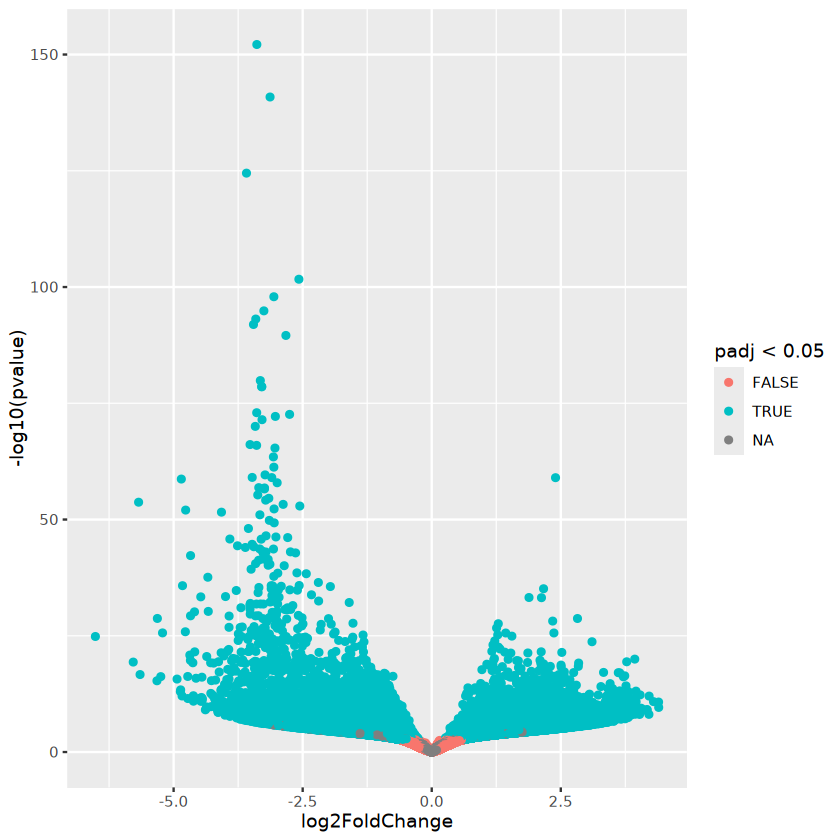

In [156]:
p

In [153]:
dim(res_tdp43)

[1] 5448004       8

In [154]:
head(res_tdp43)

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(TAACCC)n_1,0.2196139,-0.0009874006,0.3488363,0.9801307,NA,-0.07643889,3.0692087
TAR1_2,0.6830635,-0.0143460269,0.3398676,0.7799383,NA,-0.62564449,2.2392471
L1MC_3,0.5794034,-0.0140527214,0.3423779,0.7727697,NA,-0.69228632,2.3974954
MER5B_4,0.5414890,-0.0053520501,0.3460468,0.9015975,NA,-0.34180187,2.7644128
MIR3_5,1.3398256,0.0181882962,0.3193611,0.7991113,NA,0.36143617,1.4201959
(TGCTCC)n_6,6.4885142,-0.0155605628,0.2694101,0.8880365,0.9777921,-0.09230282,0.6556103


In [160]:
res_up <- res_tdp43 %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange > 0, padj < 0.05) %>%
  arrange(padj)

head(res_up)

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(GT)n_875555,427.26822,2.398075,0.1480860,9.992613e-60,5.357117e-55,2.422522,0.1486279
L1PA7_4175716,166.19660,2.166220,0.1761496,7.587689e-36,1.244274e-31,2.199455,0.1759746
L1PA6_4657682,295.01497,1.884118,0.1603286,5.851079e-34,8.407941e-30,1.914629,0.1576036
L1PBa_2842699,251.28025,2.125659,0.1784371,6.459655e-34,9.187739e-30,2.159818,0.1779050
L1MC1_3338620,90.39812,2.823446,0.2545475,1.919863e-29,2.012074e-25,2.909003,0.2581987
L1PA8_5374205,152.72031,2.343062,0.2136016,6.888044e-29,6.907271e-25,2.393903,0.2146333


In [162]:
tail(res_tdp43 %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange > 0, padj < 0.05) %>%
  arrange(log2FoldChange))

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(ACAC)n_3662293,9.325368,4.171088,0.8375582,9.812619e-10,5.642580e-07,5.956102,0.9744248
AluJr_2592574,30.213854,4.207155,1.1111781,7.914933e-09,3.302145e-06,7.433839,1.2883022
MLT1C_3325116,24.418872,4.210568,0.6606843,9.318846e-13,1.289813e-09,5.223059,0.7314994
L1PA16_3188661,19.547297,4.295724,0.7361021,1.442353e-11,1.480462e-08,5.638477,0.8348865
L1M1_2550902,23.819066,4.394139,0.7681365,1.769280e-11,1.761546e-08,5.915912,0.8798339
AluJo_3325102,9.511065,4.396489,0.8626099,2.560165e-10,1.815332e-07,6.429905,1.0168573


In [163]:
dim(res_up)

[1] 21338     8

In [165]:
dim(res_tdp43 %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange < 0, padj < 0.05) %>%
  arrange(log2FoldChange))

[1] 33398     8

In [164]:
write.csv(res_tdp43, "res_tdp43_DGE_results-correct.csv")

In [167]:
head(res_tdp43 %>%
    filter(is.na(padj)))

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(TAACCC)n_1,0.2196139,-0.0009874006,0.3488363,0.9801307,NA,-0.07643889,3.0692087
TAR1_2,0.6830635,-0.0143460269,0.3398676,0.7799383,NA,-0.62564449,2.2392471
L1MC_3,0.5794034,-0.0140527214,0.3423779,0.7727697,NA,-0.69228632,2.3974954
MER5B_4,0.5414890,-0.0053520501,0.3460468,0.9015975,NA,-0.34180187,2.7644128
MIR3_5,1.3398256,0.0181882962,0.3193611,0.7991113,NA,0.36143617,1.4201959
(TGG)n_8,5.2440367,-0.0527392550,0.2771569,0.6287628,NA,-0.33387368,0.6905793


In [171]:
repeats_saf2 <- rm_raw%>%
  transmute(
    GeneID = paste(rep_name, row_number(), sep = "_"),
    Chr = chromosome,
    Class_family = class_family,
    Start = start,
    End = end,
    Strand = case_when(
      strand == "+" ~ "+",
      strand == "C" ~ "-",
      TRUE ~ "*"
    )
  )

In [172]:
head(repeats_saf2)

GeneID,Chr,Class_family,Start,End,Strand
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
(TAACCC)n_1,chr1,Simple_repeat,10001,10468,+
TAR1_2,chr1,Satellite/telo,10469,11447,-
L1MC_3,chr1,LINE/L1,11505,11675,-
MER5B_4,chr1,DNA/hAT-Charlie,11678,11780,-
MIR3_5,chr1,SINE/MIR,15265,15355,-
(TGCTCC)n_6,chr1,Simple_repeat,15798,15849,+


In [173]:
dim(repeats_saf2)

[1] 5448004       6

In [174]:
repeats_saf2_uni <- repeats_saf2 %>% 
  distinct(GeneID, .keep_all = TRUE)

In [175]:
dim(repeats_saf2_uni)

[1] 5448004       6

In [178]:
res_tdp43_mod <- res_tdp43 %>%
  left_join(
    repeats_saf2_uni %>%
      dplyr::select(GeneID, Chr, Start, End, Strand, Class_family),
    by = c("gene_id" = "GeneID"),   
    relationship = "many-to-one"    
  )

In [179]:
dim(res_tdp43_mod)

[1] 5448004      13

In [180]:
head(res_tdp43_mod)

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE,Chr,Start,End,Strand,Class_family
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
(TAACCC)n_1,0.2196139,-0.0009874006,0.3488363,0.9801307,NA,-0.07643889,3.0692087,chr1,10001,10468,+,Simple_repeat
TAR1_2,0.6830635,-0.0143460269,0.3398676,0.7799383,NA,-0.62564449,2.2392471,chr1,10469,11447,-,Satellite/telo
L1MC_3,0.5794034,-0.0140527214,0.3423779,0.7727697,NA,-0.69228632,2.3974954,chr1,11505,11675,-,LINE/L1
MER5B_4,0.5414890,-0.0053520501,0.3460468,0.9015975,NA,-0.34180187,2.7644128,chr1,11678,11780,-,DNA/hAT-Charlie
MIR3_5,1.3398256,0.0181882962,0.3193611,0.7991113,NA,0.36143617,1.4201959,chr1,15265,15355,-,SINE/MIR
(TGCTCC)n_6,6.4885142,-0.0155605628,0.2694101,0.8880365,0.9777921,-0.09230282,0.6556103,chr1,15798,15849,+,Simple_repeat


In [181]:
write.csv(res_tdp43_mod, "res_tdp43_DGE_results-correct_with_family_info.csv")

In [183]:
res_tdp43_mod[res_tdp43_mod$gene_id=='MIR3_1729538',]

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE,Chr,Start,End,Strand,Class_family
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
MIR3_1729538,16.39805,-0.01851374,0.3508317,0.6461377,0.9123681,-1.388719,3.024646,chr16,10592026,10592079,-,SINE/MIR


In [185]:
res_tdp43_mod[res_tdp43_mod$log2FoldChange>=4,]

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE,Chr,Start,End,Strand,Class_family
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
L1MD2_730505,12.672687,4.026341,0.9161202,8.254642e-09,3.414237e-06,6.070795,1.0533770,chr11,16304800,16306312,+,LINE/L1
L1M1_2550902,23.819066,4.394139,0.7681365,1.769280e-11,1.761546e-08,5.915912,0.8798339,chr2,125335212,125339250,+,LINE/L1
AluJr_2592574,30.213854,4.207155,1.1111781,7.914933e-09,3.302145e-06,7.433839,1.2883022,chr2,149478418,149478722,-,SINE/Alu
L1PA16_3188661,19.547297,4.295724,0.7361021,1.442353e-11,1.480462e-08,5.638477,0.8348865,chr3,79700349,79701370,-,LINE/L1
AluJo_3325102,9.511065,4.396489,0.8626099,2.560165e-10,1.815332e-07,6.429905,1.0168573,chr3,160482444,160482717,-,SINE/Alu
MLT1C_3325116,24.418872,4.210568,0.6606843,9.318846e-13,1.289813e-09,5.223059,0.7314994,chr3,160487561,160488037,-,LTR/ERVL-MaLR
MSTA_3499610,13.274968,4.043183,0.7919789,9.904781e-10,5.681513e-07,5.549735,0.9081643,chr4,56284934,56285293,-,LTR/ERVL-MaLR
LTR81_3553940,14.118296,4.116394,0.8164674,9.695773e-10,5.589224e-07,5.770673,0.9437934,chr4,87843550,87843811,-,LTR/Gypsy
(ACAC)n_3662293,9.325368,4.171088,0.8375582,9.812619e-10,5.642580e-07,5.956102,0.9744248,chr4,152563143,152563202,+,Simple_repeat


In [187]:
# SINE/Alu
dim(res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange > 0, padj < 0.05, Class_family == "SINE/Alu") %>%
  arrange(log2FoldChange))

[1] 2276   13

In [188]:
dim(res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange > 0, padj < 0.05, Class_family == "LINE/L1") %>%
  arrange(log2FoldChange))

[1] 5791   13

In [189]:
dim(res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange > 0, padj < 0.05, Class_family == "LINE/L2") %>%
  arrange(log2FoldChange))

[1] 2938   13

In [195]:
dim(repeat_norm_counts_family)

[1] 76272056        8

In [196]:
head(repeat_norm_counts_family)

gene_id,sample_id,count,raw_count,class_family,chromosome,start,end
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
(TAACCC)n_1,SRR8571937,0.000000,0,Simple_repeat,chr1,10001,10468
(TAACCC)n_1,SRR8571938,1.154119,1,Simple_repeat,chr1,10001,10468
(TAACCC)n_1,SRR8571939,0.000000,0,Simple_repeat,chr1,10001,10468
(TAACCC)n_1,SRR8571940,0.000000,0,Simple_repeat,chr1,10001,10468
(TAACCC)n_1,SRR8571941,0.000000,0,Simple_repeat,chr1,10001,10468
(TAACCC)n_1,SRR8571942,0.000000,0,Simple_repeat,chr1,10001,10468


In [198]:
repeat_norm_counts_family[repeat_norm_counts_family$gene_id=="MIR3_1729538", ]

gene_id,sample_id,count,raw_count,class_family,chromosome,start,end
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
MIR3_1729538,SRR8571937,0.00000,0,SINE/MIR,chr16,10592026,10592079
MIR3_1729538,SRR8571938,0.00000,0,SINE/MIR,chr16,10592026,10592079
MIR3_1729538,SRR8571939,0.00000,0,SINE/MIR,chr16,10592026,10592079
MIR3_1729538,SRR8571940,0.00000,0,SINE/MIR,chr16,10592026,10592079
MIR3_1729538,SRR8571941,0.00000,0,SINE/MIR,chr16,10592026,10592079
MIR3_1729538,SRR8571942,0.00000,0,SINE/MIR,chr16,10592026,10592079
MIR3_1729538,SRR8571944,0.00000,0,SINE/MIR,chr16,10592026,10592079
MIR3_1729538,SRR8571945,75.11156,86,SINE/MIR,chr16,10592026,10592079
MIR3_1729538,SRR8571947,0.00000,0,SINE/MIR,chr16,10592026,10592079


In [205]:
res_tdp43_mod[res_tdp43_mod$gene_id=='MIR3_1729538',]

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE,Chr,Start,End,Strand,Class_family
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
MIR3_1729538,16.39805,-0.01851374,0.3508317,0.6461377,0.9123681,-1.388719,3.024646,chr16,10592026,10592079,-,SINE/MIR


In [204]:
repeat_counts_mat["MIR3_1729538",]

SRR8571937 SRR8571938 SRR8571939 SRR8571940 SRR8571941 SRR8571942 SRR8571944 
      0.00       0.50       0.00       0.00       0.50       0.00       0.00 
SRR8571945 SRR8571947 SRR8571948 SRR8571949 SRR8571950 SRR8571951 SRR8571952 
     85.67       0.00       0.00       0.50       0.00       0.00     109.50

In [207]:
liu_meta_fixed

,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Cell_type,Center Name,Consent,DATASTORE filetype,⋯,ReleaseDate,Sample Name,source_name,SRA Study,Tissue,genotype/variation,accession,sample_title,patient_sample_id,tdp_43_status
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dttm>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SRR8571937,RNA-Seq,240,34996399600,PRJNA522295,SAMN10926441,14893314011,NeuN positive,GEO,public,"fastq,sra",⋯,2019-03-16,GSM3603263,Nuclei,SRP185789,Frontal cortex,TDP-43 positive,SRS4361180,RNA-Seq - NeuN positive/TDP-43 positive S1,S1,TDP-43 positive
SRR8571938,RNA-Seq,239,36288552250,PRJNA522295,SAMN10926440,15501584879,NeuN positive,GEO,public,"sra,fastq",⋯,2019-03-16,GSM3603264,Nuclei,SRP185789,Frontal cortex,TDP-43 negative,SRS4361182,RNA-Seq - NeuN positive/TDP-43 negative S1,S1,TDP-43 negative
SRR8571939,RNA-Seq,239,37159091950,PRJNA522295,SAMN10926438,15906400112,NeuN positive,GEO,public,"sra,fastq",⋯,2019-03-16,GSM3603265,Nuclei,SRP185789,Frontal cortex,TDP-43 positive,SRS4361181,RNA-Seq - NeuN positive/TDP-43 positive S2,S2,TDP-43 positive
SRR8571940,RNA-Seq,240,34870008150,PRJNA522295,SAMN10926436,14666294567,NeuN positive,GEO,public,"sra,fastq",⋯,2019-03-16,GSM3603266,Nuclei,SRP185789,Frontal cortex,TDP-43 negative,SRS4361184,RNA-Seq - NeuN positive/TDP-43 negative S2,S2,TDP-43 negative
SRR8571941,RNA-Seq,235,28242749150,PRJNA522295,SAMN10926434,12913291196,NeuN positive,GEO,public,"fastq,sra",⋯,2019-03-16,GSM3603267,Nuclei,SRP185789,Frontal cortex,TDP-43 positive,SRS4361183,RNA-Seq - NeuN positive/TDP-43 positive S3,S3,TDP-43 positive
SRR8571942,RNA-Seq,237,27942136100,PRJNA522295,SAMN10926433,12477309657,NeuN positive,GEO,public,"fastq,sra",⋯,2019-03-16,GSM3603268,Nuclei,SRP185789,Frontal cortex,TDP-43 negative,SRS4361185,RNA-Seq - NeuN positive/TDP-43 negative S3,S3,TDP-43 negative
SRR8571944,RNA-Seq,236,29933976100,PRJNA522295,SAMN10926429,13541182580,NeuN positive,GEO,public,"fastq,sra",⋯,2019-03-16,GSM3603270,Nuclei,SRP185789,Frontal cortex,TDP-43 positive,SRS4361187,RNA-Seq - NeuN positive/TDP-43 positive S4,S4,TDP-43 positive
SRR8571945,RNA-Seq,236,30140134150,PRJNA522295,SAMN10926428,13593367716,NeuN positive,GEO,public,"fastq,sra",⋯,2019-03-16,GSM3603271,Nuclei,SRP185789,Frontal cortex,TDP-43 negative,SRS4361190,RNA-Seq - NeuN positive/TDP-43 negative S4,S4,TDP-43 negative
SRR8571947,RNA-Seq,238,32837216200,PRJNA522295,SAMN10926477,14544944538,NeuN positive,GEO,public,"fastq,sra",⋯,2019-03-16,GSM3603273,Nuclei,SRP185789,Frontal cortex,TDP-43 positive,SRS4361189,RNA-Seq - NeuN positive/TDP-43 positive S5,S5,TDP-43 positive


In [208]:
resultsNames(dds)        # see the coefficient names
levels(coldata$tdp_43_status)

[1] "Intercept"                 "condition_case_vs_control"

Warning message:
“Unknown or uninitialised column: `tdp_43_status`.”


NULL

In [209]:
# If you want CASE vs CONTROL explicitly:
res_case_vs_ctrl <- results(dds, contrast = c("tdp_43_status", "TDP-43 negative", "TDP-43 positive"))
# now positive log2FC = higher in case (TDP-43 negative)

ERROR: Error in cleanContrast(object, contrast, expanded = isExpanded, listValues = listValues, : tdp_43_status should be the name of a factor in the colData of the DESeqDataSet


In [210]:
head(de_meta)

Run,patient_sample_id,tdp_43_status
<chr>,<chr>,<chr>
SRR8571937,S1,TDP-43 positive
SRR8571938,S1,TDP-43 negative
SRR8571939,S2,TDP-43 positive
SRR8571940,S2,TDP-43 negative
SRR8571941,S3,TDP-43 positive
SRR8571942,S3,TDP-43 negative


In [211]:
de_meta$tdp_43_status <- relevel(de_meta$tdp_43_status, ref = "TDP-43 positive")

ERROR: Error in relevel.default(de_meta$tdp_43_status, ref = "TDP-43 positive"): 'relevel' only for (unordered) factors


In [212]:
de_meta$tdp_43_status <- factor(de_meta$tdp_43_status)
de_meta$tdp_43_status <- relevel(de_meta$tdp_43_status, ref = "TDP-43 positive")


In [213]:
levels(de_meta$tdp_43_status)

[1] "TDP-43 positive" "TDP-43 negative"

In [214]:
de <- DESeqDataSetFromMatrix(
  countData = repeat_counts_int,
  colData   = de_meta,
  design    = ~ tdp_43_status + patient_sample_id
)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [217]:
sizeFactors(de) <- liu_size_factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [218]:
des <- DESeq(de)

using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [221]:
res <- results(des, contrast = c("tdp_43_status", "TDP-43_negative", "TDP-43_positive"))


ERROR: Error in cleanContrast(object, contrast, expanded = isExpanded, listValues = listValues, : TDP-43_negative and TDP-43_positive should be levels of tdp_43_status such that tdp_43_status_TDP.43_negative_vs_TDP.43.positive and tdp_43_status_TDP.43_positive_vs_TDP.43.positive are contained in 'resultsNames(object)'


In [222]:
repeat_all_counts <- list(
  normalized = counts(des, normalized = TRUE),
  raw = counts(des, normalized = FALSE)
)

In [223]:
repeat_norm_counts_family <- repeat_all_counts %>%
  map(\(x) as_tibble(x, rownames = "gene_id")) %>%
  bind_rows(.id = "normalized") %>%
  pivot_longer(
    -c(normalized, gene_id),
    names_to = "sample_id",
    values_to = "count"
  ) %>%
  pivot_wider(
    names_from = normalized,
    values_from = count
  ) %>%
  dplyr::rename(
    count = normalized,
    raw_count = raw
  ) %>%
  power_inner_join(
    rm_raw %>%
      transmute(
        gene_id = paste(rep_name, row_number(), sep = "_"),
        class_family,
        chromosome, start, end
      ),
    by = "gene_id",
    check = check_specs(
      unmatched_keys_left = "warn",
      duplicate_keys_right = "warn"
    )
  )

In [225]:
repeat_norm_counts_family_agg <- repeat_norm_counts_family %>%
  group_by(
    sample_id, class_family
  ) %>%
  summarize(
    count = sum(count),
    raw_count = sum(raw_count),
    .groups = "drop"
  ) %>%
  semi_join(
    repeat_whitelist,
    by = "class_family"
  ) %>%
  power_inner_join(
    liu_meta %>%
      dplyr::select(Run, patient_sample_id, tdp_43_status),
    by = c("sample_id" = "Run"),
    check = check_specs(
      unmatched_keys_left = "warn",
      unmatched_keys_right = "warn",
      duplicate_keys_right = "warn"
    )
  )

Warning message:
“Keys in the right table have unmatched combinations:
# A tibble: 2 × 1
  Run       
  <chr>     
1 SRR8571943
2 SRR8571946”


In [227]:
repeat_norm_counts_family_agg_long <- repeat_norm_counts_family_agg %>%
  dplyr::select(class_family, count, patient_sample_id, tdp_43_status) %>%
  pivot_wider(
    names_from = tdp_43_status,
    values_from = count
  ) %>%
  mutate(
    difference = `TDP-43 negative` - `TDP-43 positive`,
    lratio = log2(`TDP-43 negative` / `TDP-43 positive`)
  )

In [228]:
de_agg_raw <- repeat_norm_counts_family_agg_long %>%
  group_by(
    class_family
  ) %>%
  summarize(
    res = list(
      lm(
        difference ~ 1,
        data = pick(everything())
      ) %>%
        broom::tidy()
    ),
    .groups = "drop"
  ) %>%
  unnest(res) %>%
  mutate(
    padj = p.adjust(p.value, method = "BH")
  )

In [229]:
de_agg_raw_lratio <- repeat_norm_counts_family_agg_long %>%
  group_by(
    class_family
  ) %>%
  summarize(
    res = list(
      lm(
        lratio ~ 1,
        data = pick(everything())
      ) %>%
        broom::tidy()
    ),
    .groups = "drop"
  ) %>%
  unnest(res) %>%
  mutate(
    padj = p.adjust(p.value, method = "BH"),
    estimate_fc = 2^estimate
  )

In [230]:
resultsNames(des)

[1] "Intercept"                                       
[2] "tdp_43_status_TDP.43.negative_vs_TDP.43.positive"
[3] "patient_sample_id_S2_vs_S1"                      
[4] "patient_sample_id_S3_vs_S1"                      
[5] "patient_sample_id_S4_vs_S1"                      
[6] "patient_sample_id_S5_vs_S1"                      
[7] "patient_sample_id_S6_vs_S1"                      
[8] "patient_sample_id_S7_vs_S1"

In [231]:
res_tdp43 <- extract_deseq_result(
  des,
  name = "tdp_43_status_TDP.43.negative_vs_TDP.43.positive"
)

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



In [232]:
p <- res_tdp43 %>%
  ggplot(
    aes(
      log2FoldChange,
      -log10(pvalue),
      color = padj < 0.05
    )
  ) +
  geom_point()


Warning message:
“Removed 1250425 rows containing missing values or values outside the scale range (`geom_point()`).”


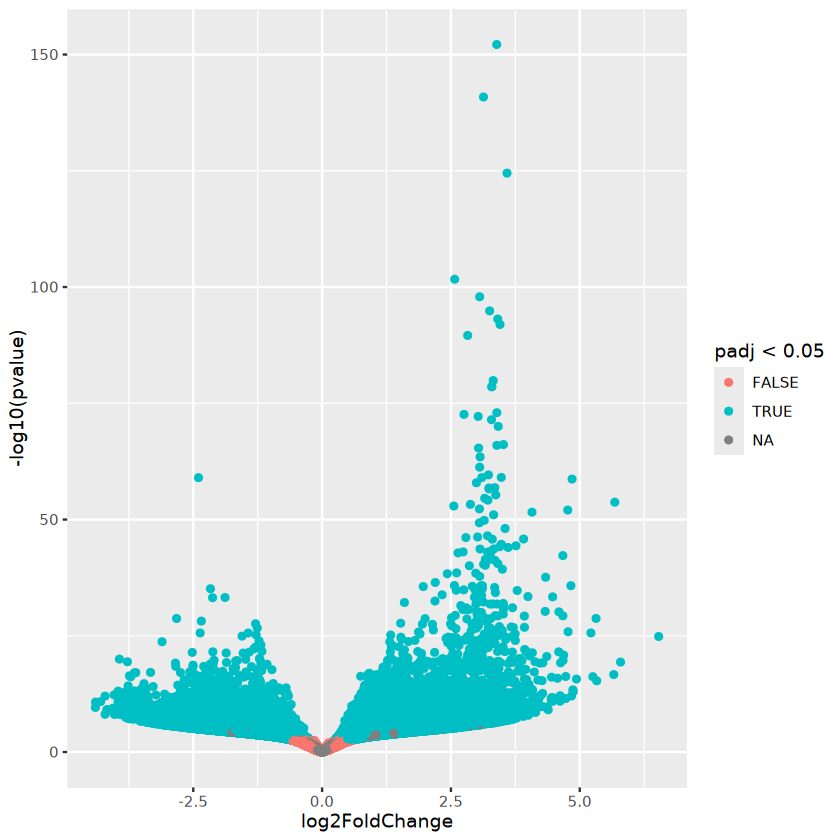

In [233]:
p

In [234]:
res_tdp43_mod <- res_tdp43 %>%
  left_join(
    repeats_saf2_uni %>%
      dplyr::select(GeneID, Chr, Start, End, Strand, Class_family),
    by = c("gene_id" = "GeneID"),   
    relationship = "many-to-one"    
  )

In [235]:
write.csv(res_tdp43_mod, "res_tdp43_DGE_results-correct_with_family_info.csv")

In [56]:
res_tdp43_mod <- read.csv("res_tdp43_DGE_results-correct_with_family_info.csv")

In [57]:
dim(res_tdp43_mod)

[1] 5448004      14

In [236]:
# SINE/Alu
dim(res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange > 0, padj < 0.05, Class_family == "SINE/Alu") %>%
  arrange(log2FoldChange))

[1] 4882   13

In [246]:
# SINE/MIR
dim(res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange > 0, padj < 0.05, Class_family == "SINE/MIR") %>%
  arrange(log2FoldChange))

[1] 3511   13

In [247]:
# LINE/L1
dim(res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange > 0, padj < 0.05, Class_family == "LINE/L1") %>%
  arrange(log2FoldChange))

[1] 7707   13

In [248]:
# LINE/L2
dim(res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange > 0, padj < 0.05, Class_family == "LINE/L2") %>%
  arrange(log2FoldChange))

[1] 4583   13

In [250]:
dim(res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange > 0, padj < 0.05))

[1] 33398    13

In [251]:
dim(res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange < 0, padj < 0.05))

[1] 21338    13

In [237]:
res_tdp43_mod[res_tdp43_mod$gene_id=='MIR3_1729538',]

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE,Chr,Start,End,Strand,Class_family
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
MIR3_1729538,16.39805,0.01851328,0.3508308,0.6461446,0.9123673,1.38869,3.024646,chr16,10592026,10592079,-,SINE/MIR


In [238]:
tail(res_tdp43 %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange > 0, padj < 0.05) %>%
  arrange(log2FoldChange))

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
L1MEc_1880756,87.33952,5.316818,0.5068616,1.869550e-29,1.974188e-25,5.968820,0.5296733
L2c_45712,24.09946,5.329302,0.7895721,4.745543e-16,1.241035e-12,7.068997,0.8707978
L2c_2321108,25.32161,5.660190,0.8229196,2.173282e-17,6.996060e-14,7.530198,0.8875622
MLT1A0_4340248,160.03654,5.679873,0.3816813,1.877018e-54,7.475253e-50,6.050473,0.3893631
L2a_2321115,40.72738,5.791884,0.7561466,4.517980e-20,2.085272e-16,7.335315,0.7994940
(TGGA)n_2321109,58.86172,6.531922,0.7698143,1.417813e-25,1.091857e-21,7.975795,0.7630061


In [243]:
res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange > 5, padj < 0.05)

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE,Chr,Start,End,Strand,Class_family
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
L2c_45712,24.09946,5.329302,0.7895721,4.745543e-16,1.241035e-12,7.068997,0.8707978,chr1,21598713,21598846,-,LINE/L2
L1ME3A_235392,44.64357,5.216897,0.5308784,2.403263e-26,2.017988e-22,5.930518,0.5584244,chr1,112072731,112074095,+,LINE/L1
L1MEc_1880756,87.33952,5.316818,0.5068616,1.869550e-29,1.974188e-25,5.968820,0.5296733,chr16,89026485,89028179,-,LINE/L1
L2c_2321108,25.32161,5.660190,0.8229196,2.173282e-17,6.996060e-14,7.530198,0.8875622,chr19,57043283,57043896,+,LINE/L2
(TGGA)n_2321109,58.86172,6.531922,0.7698143,1.417813e-25,1.091857e-21,7.975795,0.7630061,chr19,57044012,57044703,+,Simple_repeat
L2a_2321115,40.72738,5.791884,0.7561466,4.517980e-20,2.085272e-16,7.335315,0.7994940,chr19,57047780,57048262,+,LINE/L2
ERVL-E-int_4340231,29.31700,5.253899,0.7345833,6.065428e-17,1.826021e-13,6.729222,0.8045510,chr6,166396038,166396307,+,LTR/ERVL
MLT1A0_4340248,160.03654,5.679873,0.3816813,1.877018e-54,7.475253e-50,6.050473,0.3893631,chr6,166403876,166404182,-,LTR/ERVL-MaLR


In [244]:
repeat_norm_counts_family[repeat_norm_counts_family$gene_id=="MLT1A0_4340248", ]

gene_id,sample_id,count,raw_count,class_family,chromosome,start,end
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
MLT1A0_4340248,SRR8571937,3.668019,3,LTR/ERVL-MaLR,chr6,166403876,166404182
MLT1A0_4340248,SRR8571938,230.823804,200,LTR/ERVL-MaLR,chr6,166403876,166404182
MLT1A0_4340248,SRR8571939,11.989468,16,LTR/ERVL-MaLR,chr6,166403876,166404182
MLT1A0_4340248,SRR8571940,425.062182,422,LTR/ERVL-MaLR,chr6,166403876,166404182
MLT1A0_4340248,SRR8571941,3.871168,4,LTR/ERVL-MaLR,chr6,166403876,166404182
MLT1A0_4340248,SRR8571942,389.113413,362,LTR/ERVL-MaLR,chr6,166403876,166404182
MLT1A0_4340248,SRR8571944,2.959570,4,LTR/ERVL-MaLR,chr6,166403876,166404182
MLT1A0_4340248,SRR8571945,214.853992,246,LTR/ERVL-MaLR,chr6,166403876,166404182
MLT1A0_4340248,SRR8571947,13.349798,14,LTR/ERVL-MaLR,chr6,166403876,166404182


In [253]:
res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange < -4, padj < 0.05)

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE,Chr,Start,End,Strand,Class_family
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
L2c_730292,11.270748,-4.000044,0.8646442,5.277973e-09,2.338481e-06,-5.790258,0.9917946,chr11,16157567,16158111,+,LINE/L2
L1MD2_730505,12.672687,-4.028134,0.9174590,8.254504e-09,3.414180e-06,-6.070794,1.0533763,chr11,16304800,16306312,+,LINE/L1
L1M1_2550902,23.819066,-4.396195,0.7692348,1.769193e-11,1.761459e-08,-5.915911,0.8798327,chr2,125335212,125339250,+,LINE/L1
AluJr_2592574,30.213854,-4.211216,1.1140568,7.915282e-09,3.302291e-06,-7.433821,1.2883008,chr2,149478418,149478722,-,SINE/Alu
L1PA16_3188661,19.547297,-4.297311,0.7369272,1.442358e-11,1.480467e-08,-5.638471,0.8348856,chr3,79700349,79701370,-,LINE/L1
AluJo_3325102,9.511065,-4.399359,0.8643589,2.560260e-10,1.815276e-07,-6.429906,1.0168584,chr3,160482444,160482717,-,SINE/Alu
MLT1C_3325116,24.418872,-4.211620,0.6611680,9.318786e-13,1.289760e-09,-5.223057,0.7314990,chr3,160487561,160488037,-,LTR/ERVL-MaLR
MSTA_3499610,13.274968,-4.044486,0.7928329,9.905072e-10,5.681680e-07,-5.549735,0.9081650,chr4,56284934,56285293,-,LTR/ERVL-MaLR
LTR81_3553940,14.118296,-4.117993,0.8174954,9.695784e-10,5.589231e-07,-5.770673,0.9437934,chr4,87843550,87843811,-,LTR/Gypsy


In [255]:
repeat_norm_counts_family[repeat_norm_counts_family$gene_id=="L1M1_2550902", ]

gene_id,sample_id,count,raw_count,class_family,chromosome,start,end
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
L1M1_2550902,SRR8571937,9.781384,8,LINE/L1,chr2,125335212,125339250
L1M1_2550902,SRR8571938,0.000000,0,LINE/L1,chr2,125335212,125339250
L1M1_2550902,SRR8571939,26.976302,36,LINE/L1,chr2,125335212,125339250
L1M1_2550902,SRR8571940,0.000000,0,LINE/L1,chr2,125335212,125339250
L1M1_2550902,SRR8571941,72.584397,75,LINE/L1,chr2,125335212,125339250
L1M1_2550902,SRR8571942,0.000000,0,LINE/L1,chr2,125335212,125339250
L1M1_2550902,SRR8571944,41.433986,56,LINE/L1,chr2,125335212,125339250
L1M1_2550902,SRR8571945,0.000000,0,LINE/L1,chr2,125335212,125339250
L1M1_2550902,SRR8571947,20.978253,22,LINE/L1,chr2,125335212,125339250


In [257]:
res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
         log2FoldChange > 4.5, padj < 0.05, log2FoldChange < 5)

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE,Chr,Start,End,Strand,Class_family
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
MLT2B1_235327,83.31511,4.828223,0.3983771,1.672484e-36,2.950939e-32,5.192468,0.4115007,chr1,112033744,112034215,-,LTR/ERVL
(CCTCTG)n_235332,43.98016,4.686773,0.5277927,1.414764e-21,7.763826e-18,5.341981,0.5598980,chr1,112036295,112036328,+,Simple_repeat
MLT1O_235335,32.17298,4.727962,0.6267531,5.597470e-17,1.699826e-13,5.702830,0.6810643,chr1,112038595,112038676,+,LTR/ERVL-MaLR
MIRb_235336,15.47274,4.585746,0.7782877,3.202668e-12,3.912476e-09,6.196906,0.8892701,chr1,112039247,112039488,+,SINE/MIR
Charlie8_235370,18.16430,4.872970,0.7759570,1.002873e-13,1.745175e-10,6.520742,0.8763823,chr1,112058615,112058974,+,DNA/hAT-Charlie
(TC)n_235377,13.83914,4.840216,0.8205704,8.864861e-13,1.241865e-09,6.726230,0.9411169,chr1,112061892,112061931,+,Simple_repeat
L2a_235382,19.09580,4.866946,0.7562115,4.269278e-14,7.987732e-11,6.414005,0.8492540,chr1,112065155,112065244,+,LINE/L2
L1ME3A_235389,25.49311,4.567227,0.6083970,1.358911e-16,3.929791e-13,5.454416,0.6596786,chr1,112071513,112072239,+,LINE/L1
L1PA14_235473,80.68384,4.773719,0.4737981,1.365369e-26,1.160464e-22,5.297752,0.4963816,chr1,112120083,112122792,+,LINE/L1


In [263]:
dim(res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
          log2FoldChange > 0, padj < 0.05, Chr=="chr9", Class_family=="Simple_repeat"))

[1] 46 13

In [264]:
dim(res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
          log2FoldChange < 0, padj < 0.05, Chr=="chr9", Class_family=="Simple_repeat"))

[1] 83 13

In [262]:
head(res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
          log2FoldChange > 0, padj < 0.05, Chr=="chr9", Class_family=="Simple_repeat"))

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE,Chr,Start,End,Strand,Class_family
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
(GATAT)n_4903401,11.70351,0.6376452,0.7371330,1.811050e-03,0.047335207,2.5394382,0.8140303,chr9,2425217,2425308,+,Simple_repeat
(ATAATT)n_4904916,36.86865,0.6397347,0.2856733,5.268779e-04,0.020031218,1.0282758,0.2966147,chr9,3242903,3242959,+,Simple_repeat
(GT)n_4904927,33.65939,0.5789996,0.2974641,1.453595e-03,0.040732091,1.0152852,0.3188918,chr9,3249025,3249059,+,Simple_repeat
(AAAT)n_4904990,19.92747,0.7231013,0.4746929,7.553476e-04,0.025821944,1.5678603,0.4654256,chr9,3301450,3301472,+,Simple_repeat
(CA)n_4905326,40.53396,0.7677743,0.2864316,6.928093e-05,0.004552793,1.1297357,0.2839429,chr9,3500706,3500735,+,Simple_repeat
(CAAA)n_4905342,57.53647,0.5109039,0.2181996,1.230037e-03,0.036302721,0.7383493,0.2284622,chr9,3510330,3510357,+,Simple_repeat


In [ ]:
27,546,546

In [268]:
head(res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
          log2FoldChange > 0, padj < 0.05, Chr=="chr9", Class_family=="Simple_repeat", Start > 27541100 ))

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE,Chr,Start,End,Strand,Class_family
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
(GAGAATT)n_4947422,47.87158,0.6295710,0.2823980,0.0005858280,0.021598484,1.0114525,0.2941900,chr9,28118256,28118296,+,Simple_repeat
(TG)n_4947607,171.65415,0.4506884,0.1734707,0.0009723859,0.030856197,0.5870953,0.1779941,chr9,28233119,28233172,+,Simple_repeat
(GT)n_4947699,66.67825,0.6976644,0.2791510,0.0001903909,0.009633793,1.0583696,0.2836359,chr9,28287782,28287820,+,Simple_repeat
(ATTATTA)n_4948226,85.60696,0.6143583,0.2360559,0.0003023570,0.013479478,0.8820046,0.2441013,chr9,28578452,28578519,+,Simple_repeat
(AC)n_4948750,59.81464,0.6225421,0.2301163,0.0002205457,0.010724375,0.8764429,0.2372458,chr9,28908141,28908173,+,Simple_repeat
(TAATTAA)n_4949214,72.04263,0.5410420,0.2129847,0.0006180238,0.022442972,0.7571812,0.2211666,chr9,29195596,29195644,+,Simple_repeat


In [269]:
dim(res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
          log2FoldChange > 0, padj < 0.05, Chr=="chr9", Class_family=="Simple_repeat", Start > 27541100 ))

[1] 30 13

In [278]:
res_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(padj),
          log2FoldChange > 0, padj < 0.05, Chr=="chr9", Start > 27531100 ) %>%  
arrange(Start)

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE,Chr,Start,End,Strand,Class_family
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
MLT1A_4947141,30.19512,0.7159920,0.3462370,3.720745e-04,1.564015e-02,1.2360513,0.3472896,chr9,27936765,27937143,+,LTR/ERVL-MaLR
LTR60B_4947233,111.04816,0.7110689,0.3030809,2.334897e-04,1.116925e-02,1.1261573,0.3060443,chr9,27994684,27995035,+,LTR/ERV1
L1MA4_4947235,52.60265,0.5702055,0.2350199,6.450166e-04,2.312616e-02,0.8367574,0.2452437,chr9,27996022,27996904,+,LINE/L1
MER6_4947247,119.22219,0.6132701,0.2476526,4.074738e-04,1.668167e-02,0.9084357,0.2569690,chr9,28002676,28003326,+,DNA/TcMar-Tigger
MIR_4947288,91.02587,0.6300456,0.2431436,2.734109e-04,1.252770e-02,0.9134344,0.2509938,chr9,28029715,28029833,+,SINE/MIR
MER5A_4947309,87.18725,0.6773921,0.2142893,4.090616e-05,3.062042e-03,0.8965891,0.2185576,chr9,28046308,28046480,-,DNA/hAT-Charlie
L2b_4947321,193.04500,0.4569636,0.1881611,1.454544e-03,4.075057e-02,0.6200988,0.1947789,chr9,28052931,28053388,-,LINE/L2
MIRc_4947346,129.64895,0.4502217,0.1926594,1.904292e-03,4.896810e-02,0.6219477,0.2003203,chr9,28067748,28067922,-,SINE/MIR
MLT1A_4947347,154.06671,0.5537957,0.1932152,2.406834e-04,1.141995e-02,0.7299212,0.1987817,chr9,28068168,28068547,-,LTR/ERVL-MaLR


# Gene level DGE analysis

In [83]:
type(liu_salmon)

[1] "list"

In [100]:
head(liu_meta_fixed)

,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Cell_type,Center Name,Consent,DATASTORE filetype,⋯,ReleaseDate,Sample Name,source_name,SRA Study,Tissue,genotype/variation,accession,sample_title,patient_sample_id,tdp_43_status
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dttm>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SRR8571937,RNA-Seq,240,34996399600,PRJNA522295,SAMN10926441,14893314011,NeuN positive,GEO,public,"fastq,sra",⋯,2019-03-16,GSM3603263,Nuclei,SRP185789,Frontal cortex,TDP-43 positive,SRS4361180,RNA-Seq - NeuN positive/TDP-43 positive S1,S1,TDP-43 positive
SRR8571938,RNA-Seq,239,36288552250,PRJNA522295,SAMN10926440,15501584879,NeuN positive,GEO,public,"sra,fastq",⋯,2019-03-16,GSM3603264,Nuclei,SRP185789,Frontal cortex,TDP-43 negative,SRS4361182,RNA-Seq - NeuN positive/TDP-43 negative S1,S1,TDP-43 negative
SRR8571939,RNA-Seq,239,37159091950,PRJNA522295,SAMN10926438,15906400112,NeuN positive,GEO,public,"sra,fastq",⋯,2019-03-16,GSM3603265,Nuclei,SRP185789,Frontal cortex,TDP-43 positive,SRS4361181,RNA-Seq - NeuN positive/TDP-43 positive S2,S2,TDP-43 positive
SRR8571940,RNA-Seq,240,34870008150,PRJNA522295,SAMN10926436,14666294567,NeuN positive,GEO,public,"sra,fastq",⋯,2019-03-16,GSM3603266,Nuclei,SRP185789,Frontal cortex,TDP-43 negative,SRS4361184,RNA-Seq - NeuN positive/TDP-43 negative S2,S2,TDP-43 negative
SRR8571941,RNA-Seq,235,28242749150,PRJNA522295,SAMN10926434,12913291196,NeuN positive,GEO,public,"fastq,sra",⋯,2019-03-16,GSM3603267,Nuclei,SRP185789,Frontal cortex,TDP-43 positive,SRS4361183,RNA-Seq - NeuN positive/TDP-43 positive S3,S3,TDP-43 positive
SRR8571942,RNA-Seq,237,27942136100,PRJNA522295,SAMN10926433,12477309657,NeuN positive,GEO,public,"fastq,sra",⋯,2019-03-16,GSM3603268,Nuclei,SRP185789,Frontal cortex,TDP-43 negative,SRS4361185,RNA-Seq - NeuN positive/TDP-43 negative S3,S3,TDP-43 negative


In [94]:
str(liu_salmon)

List of 4
 $ abundance          : num [1:35278, 1:14] 1.591 0.132 39.884 6.458 10.121 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:35278] "ENSG00000000003" "ENSG00000000005" "ENSG00000000419" "ENSG00000000457" ...
  .. ..$ : chr [1:14] "SRR8571937" "SRR8571938" "SRR8571939" "SRR8571940" ...
 $ counts             : num [1:35278, 1:14] 16.1 1 546.8 254 210.3 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:35278] "ENSG00000000003" "ENSG00000000005" "ENSG00000000419" "ENSG00000000457" ...
  .. ..$ : chr [1:14] "SRR8571937" "SRR8571938" "SRR8571939" "SRR8571940" ...
 $ length             : num [1:35278, 1:14] 1202 905 1633 4686 2476 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:35278] "ENSG00000000003" "ENSG00000000005" "ENSG00000000419" "ENSG00000000457" ...
  .. ..$ : chr [1:14] "SRR8571937" "SRR8571938" "SRR8571939" "SRR8571940" ...
 $ countsFromAbundance: chr "no"


In [58]:
rownames(liu_meta_fixed)

[1] "SRR8571937" "SRR8571938" "SRR8571939" "SRR8571940" "SRR8571941"
 [6] "SRR8571942" "SRR8571944" "SRR8571945" "SRR8571947" "SRR8571948"
[11] "SRR8571949" "SRR8571950" "SRR8571951" "SRR8571952"

In [98]:
#dds2 <- DESeqDataSetFromTximport(liu_salmon, liu_meta_fixed, ~condition)

In [ ]:
liu_meta_fixed

In [59]:
dds2 <- DESeqDataSetFromTximport(
  liu_salmon,
  liu_meta_fixed %>% mutate(tdp_43_status = fct_relevel(tdp_43_status, "TDP-43 positive")) %>%
    slice(match(colnames(liu_salmon[["counts"]]), rownames(.))),
  design = ~ tdp_43_status + patient_sample_id
)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

using counts and average transcript lengths from tximport



In [60]:
head(dds2)

class: DESeqDataSet 
dim: 6 14 
metadata(1): version
assays(2): counts avgTxLength
rownames(6): ENSG00000000003 ENSG00000000005 ... ENSG00000000460
  ENSG00000000938
rowData names(0):
colnames(14): SRR8571937 SRR8571938 ... SRR8571951 SRR8571952
colData names(32): Assay Type AvgSpotLen ... patient_sample_id
  tdp_43_status

In [37]:
# 2) gene annotation GTF (Ensembl/Gencode). 
#    If your ISG list is by gene SYMBOL, set GTF.attrType="gene_name".
#    If it's Ensembl IDs, use "gene_id".
gtf <- "~/scr_proj/tdp-43/data/ref/Homo_sapiens.GRCh38.113.gtf"

In [38]:
fc <- qread("/n/scratch/users/r/rob6090/projects/tdp-43/scripts/analysis/final_dsRNA/liu_gene_counts.qs")

In [39]:
counts <- fc$counts
ann    <- fc$annotation

In [40]:
# Extract the count matrix from your featureCounts results
count_matrix <- fc$counts

In [41]:
sample_info <- data.frame(
  sample_name = colnames(count_matrix),
  condition = factor(c("TDP43_positive","TDP43_negative","TDP43_positive","TDP43_negative","TDP43_positive","TDP43_negative","TDP43_positive","TDP43_negative","TDP43_positive","TDP43_negative","TDP43_positive","TDP43_negative","TDP43_positive","TDP43_negative")) # Adjust this to your actual sample conditions
)

In [42]:
rownames(sample_info) <- colnames(count_matrix)

In [43]:
# --- FIX: Round the fractional counts to the nearest integer ---
count_matrix <- round(count_matrix)

In [286]:
liu_meta

Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Cell_type,Center Name,Consent,⋯,ReleaseDate,Sample Name,source_name,SRA Study,Tissue,genotype/variation,accession,sample_title,patient_sample_id,tdp_43_status
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,⋯,<dttm>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SRR8571937,RNA-Seq,240,34996399600,PRJNA522295,SAMN10926441,14893314011,NeuN positive,GEO,public,⋯,2019-03-16,GSM3603263,Nuclei,SRP185789,Frontal cortex,TDP-43 positive,SRS4361180,RNA-Seq - NeuN positive/TDP-43 positive S1,S1,TDP-43 positive
SRR8571938,RNA-Seq,239,36288552250,PRJNA522295,SAMN10926440,15501584879,NeuN positive,GEO,public,⋯,2019-03-16,GSM3603264,Nuclei,SRP185789,Frontal cortex,TDP-43 negative,SRS4361182,RNA-Seq - NeuN positive/TDP-43 negative S1,S1,TDP-43 negative
SRR8571939,RNA-Seq,239,37159091950,PRJNA522295,SAMN10926438,15906400112,NeuN positive,GEO,public,⋯,2019-03-16,GSM3603265,Nuclei,SRP185789,Frontal cortex,TDP-43 positive,SRS4361181,RNA-Seq - NeuN positive/TDP-43 positive S2,S2,TDP-43 positive
SRR8571940,RNA-Seq,240,34870008150,PRJNA522295,SAMN10926436,14666294567,NeuN positive,GEO,public,⋯,2019-03-16,GSM3603266,Nuclei,SRP185789,Frontal cortex,TDP-43 negative,SRS4361184,RNA-Seq - NeuN positive/TDP-43 negative S2,S2,TDP-43 negative
SRR8571941,RNA-Seq,235,28242749150,PRJNA522295,SAMN10926434,12913291196,NeuN positive,GEO,public,⋯,2019-03-16,GSM3603267,Nuclei,SRP185789,Frontal cortex,TDP-43 positive,SRS4361183,RNA-Seq - NeuN positive/TDP-43 positive S3,S3,TDP-43 positive
SRR8571942,RNA-Seq,237,27942136100,PRJNA522295,SAMN10926433,12477309657,NeuN positive,GEO,public,⋯,2019-03-16,GSM3603268,Nuclei,SRP185789,Frontal cortex,TDP-43 negative,SRS4361185,RNA-Seq - NeuN positive/TDP-43 negative S3,S3,TDP-43 negative
SRR8571943,RNA-Seq,200,4967841800,PRJNA522295,SAMN10926431,3377214530,unsorted,GEO,public,⋯,2019-03-16,GSM3603269,Nuclei,SRP185789,Frontal cortex,NA,SRS4361186,RNA-Seq - Unsorted S3,S3,NA
SRR8571944,RNA-Seq,236,29933976100,PRJNA522295,SAMN10926429,13541182580,NeuN positive,GEO,public,⋯,2019-03-16,GSM3603270,Nuclei,SRP185789,Frontal cortex,TDP-43 positive,SRS4361187,RNA-Seq - NeuN positive/TDP-43 positive S4,S4,TDP-43 positive
SRR8571945,RNA-Seq,236,30140134150,PRJNA522295,SAMN10926428,13593367716,NeuN positive,GEO,public,⋯,2019-03-16,GSM3603271,Nuclei,SRP185789,Frontal cortex,TDP-43 negative,SRS4361190,RNA-Seq - NeuN positive/TDP-43 negative S4,S4,TDP-43 negative


In [44]:
head(counts)

,SRR8571937.sorted.bam,SRR8571938.sorted.bam,SRR8571939.sorted.bam,SRR8571940.sorted.bam,SRR8571941.sorted.bam,SRR8571942.sorted.bam,SRR8571944.sorted.bam,SRR8571945.sorted.bam,SRR8571947.sorted.bam,SRR8571948.sorted.bam,SRR8571949.sorted.bam,SRR8571950.sorted.bam,SRR8571951.sorted.bam,SRR8571952.sorted.bam
ENSG00000142611,77,73,43,30,54,38,20,57,43,80,32,32,41,80
ENSG00000284616,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000157911,14,24,36,19,29,64,9,8,17,33,28,39,0,0
ENSG00000260972,0,0,0,0,2,0,0,0,0,0,2,2,0,0
ENSG00000224340,1,1,1,0,0,0,1,0,1,7,0,6,0,0
ENSG00000229280,0,6,0,3,0,3,0,0,0,3,0,0,0,0


In [45]:
colnames(counts) <- c('SRR8571937','SRR8571938','SRR8571939','SRR8571940','SRR8571941','SRR8571942','SRR8571944','SRR8571945','SRR8571947','SRR8571948','SRR8571949','SRR8571950','SRR8571951','SRR8571952')   

In [73]:
dim(liu_meta_fixed)

[1] 14 32

In [74]:
head(liu_meta_fixed)

,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Cell_type,Center Name,Consent,DATASTORE filetype,⋯,ReleaseDate,Sample Name,source_name,SRA Study,Tissue,genotype/variation,accession,sample_title,patient_sample_id,tdp_43_status
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dttm>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SRR8571937,RNA-Seq,240,34996399600,PRJNA522295,SAMN10926441,14893314011,NeuN positive,GEO,public,"fastq,sra",⋯,2019-03-16,GSM3603263,Nuclei,SRP185789,Frontal cortex,TDP-43 positive,SRS4361180,RNA-Seq - NeuN positive/TDP-43 positive S1,S1,TDP-43 positive
SRR8571938,RNA-Seq,239,36288552250,PRJNA522295,SAMN10926440,15501584879,NeuN positive,GEO,public,"sra,fastq",⋯,2019-03-16,GSM3603264,Nuclei,SRP185789,Frontal cortex,TDP-43 negative,SRS4361182,RNA-Seq - NeuN positive/TDP-43 negative S1,S1,TDP-43 negative
SRR8571939,RNA-Seq,239,37159091950,PRJNA522295,SAMN10926438,15906400112,NeuN positive,GEO,public,"sra,fastq",⋯,2019-03-16,GSM3603265,Nuclei,SRP185789,Frontal cortex,TDP-43 positive,SRS4361181,RNA-Seq - NeuN positive/TDP-43 positive S2,S2,TDP-43 positive
SRR8571940,RNA-Seq,240,34870008150,PRJNA522295,SAMN10926436,14666294567,NeuN positive,GEO,public,"sra,fastq",⋯,2019-03-16,GSM3603266,Nuclei,SRP185789,Frontal cortex,TDP-43 negative,SRS4361184,RNA-Seq - NeuN positive/TDP-43 negative S2,S2,TDP-43 negative
SRR8571941,RNA-Seq,235,28242749150,PRJNA522295,SAMN10926434,12913291196,NeuN positive,GEO,public,"fastq,sra",⋯,2019-03-16,GSM3603267,Nuclei,SRP185789,Frontal cortex,TDP-43 positive,SRS4361183,RNA-Seq - NeuN positive/TDP-43 positive S3,S3,TDP-43 positive
SRR8571942,RNA-Seq,237,27942136100,PRJNA522295,SAMN10926433,12477309657,NeuN positive,GEO,public,"fastq,sra",⋯,2019-03-16,GSM3603268,Nuclei,SRP185789,Frontal cortex,TDP-43 negative,SRS4361185,RNA-Seq - NeuN positive/TDP-43 negative S3,S3,TDP-43 negative


In [302]:
de2 <- DESeqDataSetFromMatrix(
  counts,
  de_meta,
  design = ~ tdp_43_status + patient_sample_id
)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [303]:
sizeFactors(de2) <- liu_size_factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [ ]:
sizeFactors(de2) <- liu_size_factors

In [304]:
des2 <- DESeq(de2)

using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



## updated code beloew

In [61]:
des2 <- DESeq(dds2)

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

using 'avgTxLength' from assays(dds), correcting for library size

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [62]:
df_all_counts <- list(
  normalized = counts(des2, normalized = TRUE),
  raw = counts(des2, normalized = FALSE)
)

In [63]:
df_norm_counts_family <- df_all_counts %>%
  map(\(x) as_tibble(x, rownames = "gene_id")) %>%
  bind_rows(.id = "normalized") %>%
  pivot_longer(
    -c(normalized, gene_id),
    names_to = "sample_id",
    values_to = "count"
  ) %>%
  pivot_wider(
    names_from = normalized,
    values_from = count
  ) %>%
  dplyr::rename(
    count = normalized,
    raw_count = raw
  ) 

In [64]:
des2

class: DESeqDataSet 
dim: 35278 14 
metadata(1): version
assays(6): counts avgTxLength ... H cooks
rownames(35278): ENSG00000000003 ENSG00000000005 ... ENSG00000291316
  ENSG00000291317
rowData names(46): baseMean baseVar ... deviance maxCooks
colnames(14): SRR8571937 SRR8571938 ... SRR8571951 SRR8571952
colData names(32): Assay Type AvgSpotLen ... patient_sample_id
  tdp_43_status

In [308]:
resultsNames(des2)

[1] "Intercept"                                       
[2] "tdp_43_status_TDP.43.negative_vs_TDP.43.positive"
[3] "patient_sample_id_S2_vs_S1"                      
[4] "patient_sample_id_S3_vs_S1"                      
[5] "patient_sample_id_S4_vs_S1"                      
[6] "patient_sample_id_S5_vs_S1"                      
[7] "patient_sample_id_S6_vs_S1"                      
[8] "patient_sample_id_S7_vs_S1"

In [309]:
gene_tdp43 <- extract_deseq_result(
  des2,
  name = "tdp_43_status_TDP.43.negative_vs_TDP.43.positive"
)

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



In [310]:
dim(gene_tdp43)

[1] 78932     8

In [311]:
head(gene_tdp43)

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000142611,52.5512290,0.167928836,0.2183923,0.1887152,0.4533620,0.4164406,0.3168320
ENSG00000284616,0.0000000,0.000000000,0.4350956,NA,NA,NA,NA
ENSG00000157911,22.2135438,0.145011420,0.2542025,0.2521253,0.5310823,0.4936595,0.4310675
ENSG00000260972,0.4147727,-0.007098022,0.4089405,0.8968589,NA,-0.3954945,3.0509410
ENSG00000224340,1.1928301,0.007984382,0.3871580,0.9105234,NA,0.2367735,2.1069310
ENSG00000229280,1.1253220,0.050252293,0.4240807,0.3718350,NA,2.7156771,3.0409309


Warning message:
“Removed 10503 rows containing missing values or values outside the scale range (`geom_point()`).”


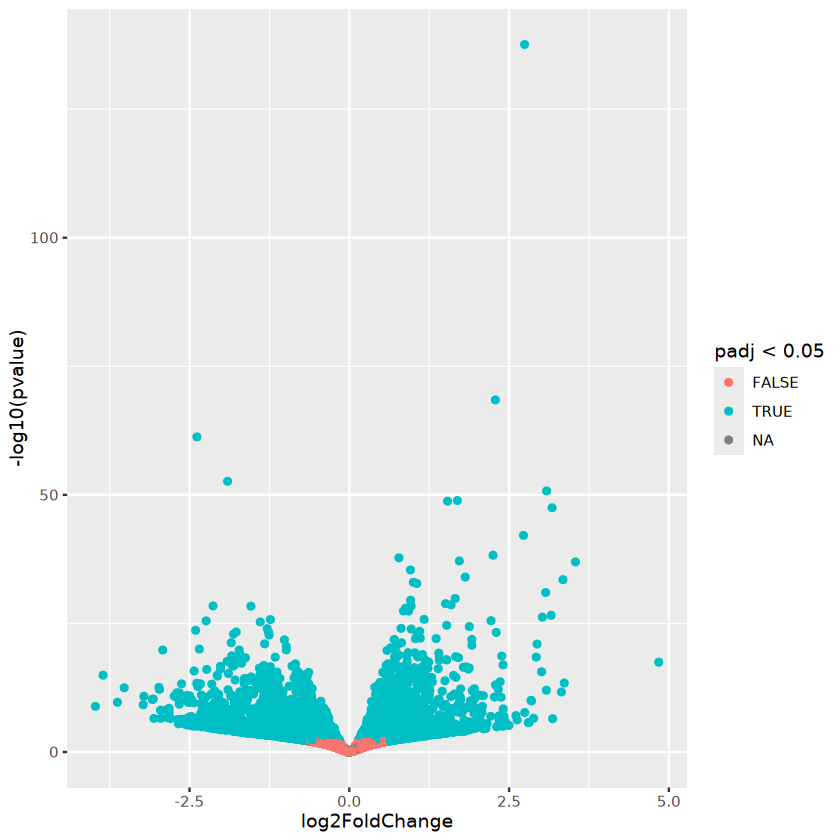

In [312]:
p <- gene_tdp43 %>%
  ggplot(
    aes(
      log2FoldChange,
      -log10(pvalue),
      color = padj < 0.05
    )
  ) +
  geom_point()

p

In [327]:
head(gene_tdp43)

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000142611,52.5512290,0.167928836,0.2183923,0.1887152,0.4533620,0.4164406,0.3168320
ENSG00000284616,0.0000000,0.000000000,0.4350956,NA,NA,NA,NA
ENSG00000157911,22.2135438,0.145011420,0.2542025,0.2521253,0.5310823,0.4936595,0.4310675
ENSG00000260972,0.4147727,-0.007098022,0.4089405,0.8968589,NA,-0.3954945,3.0509410
ENSG00000224340,1.1928301,0.007984382,0.3871580,0.9105234,NA,0.2367735,2.1069310
ENSG00000229280,1.1253220,0.050252293,0.4240807,0.3718350,NA,2.7156771,3.0409309


In [328]:
head(gene_tdp43 %>%
  arrange(desc(log2FoldChange)))

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000308506,28.668029,4.840654,0.6618202,3.466385e-18,1.372891e-15,5.814765,0.6687433
ENSG00000231246,223.410669,3.538559,0.2875335,1.080025e-37,3.389117e-34,3.718447,0.2897708
ENSG00000140678,90.000332,3.363217,0.5012486,3.794470e-14,6.972596e-12,3.918038,0.5177212
ENSG00000013588,146.742135,3.342109,0.2849831,3.057962e-34,7.796657e-31,3.516313,0.2881910
ENSG00000198796,24.126398,3.318816,0.5435959,2.100803e-12,2.769368e-10,3.975138,0.5656446
ENSG00000275874,8.325469,3.180406,1.1617912,3.339887e-07,1.285352e-05,6.093271,1.1940140


In [331]:
dim(gene_tdp43)

[1] 78932     8

In [334]:
res_dfx <- as.data.frame(gene_tdp43) %>%
  dplyr::rename(log2FoldChange = log2FoldChange, pvalue = pvalue, padj = padj) 

In [335]:
dim(res_dfx)

[1] 78932     8

In [336]:
head(res_dfx)

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000142611,52.5512290,0.167928836,0.2183923,0.1887152,0.4533620,0.4164406,0.3168320
2,ENSG00000284616,0.0000000,0.000000000,0.4350956,NA,NA,NA,NA
3,ENSG00000157911,22.2135438,0.145011420,0.2542025,0.2521253,0.5310823,0.4936595,0.4310675
4,ENSG00000260972,0.4147727,-0.007098022,0.4089405,0.8968589,NA,-0.3954945,3.0509410
5,ENSG00000224340,1.1928301,0.007984382,0.3871580,0.9105234,NA,0.2367735,2.1069310
6,ENSG00000229280,1.1253220,0.050252293,0.4240807,0.3718350,NA,2.7156771,3.0409309


In [342]:
dim(res_dfx %>%
  filter(!is.na(log2FoldChange), !is.na(pvalue)) %>%
  arrange(desc(log2FoldChange)))

[1] 68429     8

In [344]:
head((res_dfx %>%
  filter(!is.na(log2FoldChange), !is.na(pvalue)) %>%
  arrange(desc(log2FoldChange))),n=10)

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000308506,28.668029,4.840654,0.6618202,3.466385e-18,1.372891e-15,5.814765,0.6687433
2,ENSG00000231246,223.410669,3.538559,0.2875335,1.080025e-37,3.389117e-34,3.718447,0.2897708
3,ENSG00000140678,90.000332,3.363217,0.5012486,3.794470e-14,6.972596e-12,3.918038,0.5177212
4,ENSG00000013588,146.742135,3.342109,0.2849831,3.057962e-34,7.796657e-31,3.516313,0.2881910
5,ENSG00000198796,24.126398,3.318816,0.5435959,2.100803e-12,2.769368e-10,3.975138,0.5656446
6,ENSG00000275874,8.325469,3.180406,1.1617912,3.339887e-07,1.285352e-05,6.093271,1.1940140
7,ENSG00000272002,297.545959,3.172245,0.2225429,3.178176e-48,1.620631e-44,3.275620,0.2244872
8,ENSG00000167414,118.869525,3.158972,0.3048653,2.607370e-27,3.545502e-24,3.354699,0.3098894
9,ENSG00000223145,609.367904,3.086771,0.2086291,1.696167e-51,1.383869e-47,3.176238,0.2103895


In [354]:
dim(res_dfx %>%
  filter(!is.na(log2FoldChange), !is.na(pvalue),
          log2FoldChange > 0, padj < 0.05) %>%
  arrange(desc(log2FoldChange)))

[1] 3284    8

In [353]:
head(res_dfx %>%
  filter(!is.na(log2FoldChange), !is.na(pvalue),
          log2FoldChange > 0, padj < 0.05) %>%
  arrange(desc(log2FoldChange)),n=10)

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000308506,28.668029,4.840654,0.6618202,3.466385e-18,1.372891e-15,5.814765,0.6687433
2,ENSG00000231246,223.410669,3.538559,0.2875335,1.080025e-37,3.389117e-34,3.718447,0.2897708
3,ENSG00000140678,90.000332,3.363217,0.5012486,3.794470e-14,6.972596e-12,3.918038,0.5177212
4,ENSG00000013588,146.742135,3.342109,0.2849831,3.057962e-34,7.796657e-31,3.516313,0.2881910
5,ENSG00000198796,24.126398,3.318816,0.5435959,2.100803e-12,2.769368e-10,3.975138,0.5656446
6,ENSG00000275874,8.325469,3.180406,1.1617912,3.339887e-07,1.285352e-05,6.093271,1.1940140
7,ENSG00000272002,297.545959,3.172245,0.2225429,3.178176e-48,1.620631e-44,3.275620,0.2244872
8,ENSG00000167414,118.869525,3.158972,0.3048653,2.607370e-27,3.545502e-24,3.354699,0.3098894
9,ENSG00000223145,609.367904,3.086771,0.2086291,1.696167e-51,1.383869e-47,3.176238,0.2103895


In [356]:
head(res_dfx %>%
  filter(!is.na(log2FoldChange), !is.na(pvalue),
          log2FoldChange < 0, padj < 0.05) %>%
  arrange((log2FoldChange)),n=10)

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000305064,12.67040,-3.973319,0.9561689,1.325389e-09,9.419501e-08,-6.127405,1.0104079
2,ENSG00000231453,40.32952,-3.853479,0.5589930,1.159882e-15,2.994699e-13,-4.543530,0.5673288
3,ENSG00000229771,20.27771,-3.628162,0.7277424,2.083385e-10,1.748757e-08,-4.836766,0.7610883
4,ENSG00000152595,252.80934,-3.522491,0.5624227,3.219283e-13,4.993438e-11,-4.228237,0.5804118
5,ENSG00000232631,49.10953,-3.224740,0.6307638,6.413719e-10,4.887203e-08,-4.119292,0.6665615
6,ENSG00000122025,142.30657,-3.214866,0.5494398,1.440280e-11,1.583687e-09,-3.883148,0.5749580
7,ENSG00000157404,579.51548,-3.081831,0.5414522,5.974438e-11,5.602787e-09,-3.723243,0.5689225
8,ENSG00000145681,54.67909,-3.079292,0.5389555,5.360026e-11,5.085044e-09,-3.714303,0.5661549
9,ENSG00000259417,157.14087,-3.067539,0.5347504,4.943820e-11,4.779104e-09,-3.691372,0.5616288


In [345]:
dim(res_dfx)

[1] 78932     8

In [346]:
write.csv(res_dfx, "res_tdp43_genes_DGE_results-correct.csv")

In [360]:
res_dfx[res_dfx$gene_id=="ENSG00000134018",]

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


# analysis for the overlap plots

In [116]:
res_dfx <- read.csv("res_tdp43_genes_DGE_results-correct.csv")

In [117]:
dim(res_dfx)

[1] 78932     9

In [119]:
dim(res_dfx[!is.na(res_dfx$pvalue), ])

[1] 68429     9

In [36]:
head(res_dfx)

,X,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,ENSG00000142611,52.5512290,0.167928836,0.2183923,0.1887152,0.4533620,0.4164406,0.3168320
2,2,ENSG00000284616,0.0000000,0.000000000,0.4350956,NA,NA,NA,NA
3,3,ENSG00000157911,22.2135438,0.145011420,0.2542025,0.2521253,0.5310823,0.4936595,0.4310675
4,4,ENSG00000260972,0.4147727,-0.007098022,0.4089405,0.8968589,NA,-0.3954945,3.0509410
5,5,ENSG00000224340,1.1928301,0.007984382,0.3871580,0.9105234,NA,0.2367735,2.1069310
6,6,ENSG00000229280,1.1253220,0.050252293,0.4240807,0.3718350,NA,2.7156771,3.0409309


In [75]:
head(res_tdp43_mod)

,X,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE,Chr,Start,End,Strand,Class_family
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,1,(TAACCC)n_1,0.2196139,0.0009872921,0.3488357,0.9801328,NA,0.07643074,3.0692087,chr1,10001,10468,+,Simple_repeat
2,2,TAR1_2,0.6830635,0.0143456684,0.3398672,0.7799425,NA,0.62563369,2.2392524,chr1,10469,11447,-,Satellite/telo
3,3,L1MC_3,0.5794034,0.0140526084,0.3423776,0.7727705,NA,0.69228515,2.3975008,chr1,11505,11675,-,LINE/L1
4,4,MER5B_4,0.5414890,0.0053519550,0.3460465,0.9015989,NA,0.34179721,2.7644156,chr1,11678,11780,-,DNA/hAT-Charlie
5,5,MIR3_5,1.3398256,-0.0181870820,0.3193529,0.7991126,NA,-0.36143511,1.4202007,chr1,15265,15355,-,SINE/MIR
6,6,(TGCTCC)n_6,6.4885142,0.0155478257,0.2693022,0.8880359,0.9777899,0.09230360,0.6556122,chr1,15798,15849,+,Simple_repeat


In [77]:
colnames(res_tdp43_mod)

[1] "X"                  "gene_id"            "baseMean"          
 [4] "log2FoldChange"     "lfcSE"              "pvalue"            
 [7] "padj"               "log2FoldChange_MLE" "lfcSE_MLE"         
[10] "Chr"                "Start"              "End"               
[13] "Strand"             "Class_family"

In [78]:
te <- res_tdp43_mod[,c('gene_id','baseMean','log2FoldChange','lfcSE','pvalue','padj','log2FoldChange_MLE','lfcSE_MLE','Chr','Start','End','Strand','Class_family')] 



In [79]:
colnames(te) <- c('GeneID','baseMean','log2FoldChange','lfcSE',
                             'pvalue','padj','log2FoldChange_MLE','lfcSE_MLE','Chr','Start','End','Strand','Class_family')

In [80]:
head(te)

,GeneID,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE,Chr,Start,End,Strand,Class_family
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,(TAACCC)n_1,0.2196139,0.0009872921,0.3488357,0.9801328,NA,0.07643074,3.0692087,chr1,10001,10468,+,Simple_repeat
2,TAR1_2,0.6830635,0.0143456684,0.3398672,0.7799425,NA,0.62563369,2.2392524,chr1,10469,11447,-,Satellite/telo
3,L1MC_3,0.5794034,0.0140526084,0.3423776,0.7727705,NA,0.69228515,2.3975008,chr1,11505,11675,-,LINE/L1
4,MER5B_4,0.5414890,0.0053519550,0.3460465,0.9015989,NA,0.34179721,2.7644156,chr1,11678,11780,-,DNA/hAT-Charlie
5,MIR3_5,1.3398256,-0.0181870820,0.3193529,0.7991126,NA,-0.36143511,1.4202007,chr1,15265,15355,-,SINE/MIR
6,(TGCTCC)n_6,6.4885142,0.0155478257,0.2693022,0.8880359,0.9777899,0.09230360,0.6556122,chr1,15798,15849,+,Simple_repeat


# updated analysis

In [65]:
resultsNames(des2)

[1] "Intercept"                                       
[2] "tdp_43_status_TDP.43.negative_vs_TDP.43.positive"
[3] "patient_sample_id_S2_vs_S1"                      
[4] "patient_sample_id_S3_vs_S1"                      
[5] "patient_sample_id_S4_vs_S1"                      
[6] "patient_sample_id_S5_vs_S1"                      
[7] "patient_sample_id_S6_vs_S1"                      
[8] "patient_sample_id_S7_vs_S1"

In [66]:
gene_tdp43 <- extract_deseq_result(
  des2,
  name = "tdp_43_status_TDP.43.negative_vs_TDP.43.positive"
)

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



In [67]:
head(gene_tdp43)

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000000003,31.121949,-0.15800009,0.2969512,0.1602938,0.4368886,-0.80269676,0.5716871
ENSG00000000005,2.044308,-0.03350080,0.3347891,0.6626342,NA,-0.61549283,1.4107774
ENSG00000000419,762.968743,0.02547822,0.1123275,0.7805052,0.9218402,0.03827172,0.1373416
ENSG00000000457,408.923459,-0.14147748,0.1312884,0.1646449,0.4440297,-0.21786582,0.1567811
ENSG00000000460,240.495230,-0.02532049,0.1463085,0.8101915,0.9339985,-0.04860270,0.2023603
ENSG00000000938,2.365039,0.01600225,0.3348916,0.8288951,NA,0.32471871,1.5025010


In [68]:
dim(gene_tdp43)

[1] 35278     8

In [69]:
dim(gene_tdp43[!is.na(gene_tdp43$pvalue), ])

[1] 29439     8

In [70]:
gene_tdp43_mod <- gene_tdp43[!is.na(gene_tdp43$pvalue), ]

In [71]:
head(gene_tdp43_mod)

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000000003,31.121949,-0.15800009,0.2969512,0.1602938,0.4368886,-0.80269676,0.5716871
ENSG00000000005,2.044308,-0.03350080,0.3347891,0.6626342,NA,-0.61549283,1.4107774
ENSG00000000419,762.968743,0.02547822,0.1123275,0.7805052,0.9218402,0.03827172,0.1373416
ENSG00000000457,408.923459,-0.14147748,0.1312884,0.1646449,0.4440297,-0.21786582,0.1567811
ENSG00000000460,240.495230,-0.02532049,0.1463085,0.8101915,0.9339985,-0.04860270,0.2023603
ENSG00000000938,2.365039,0.01600225,0.3348916,0.8288951,NA,0.32471871,1.5025010


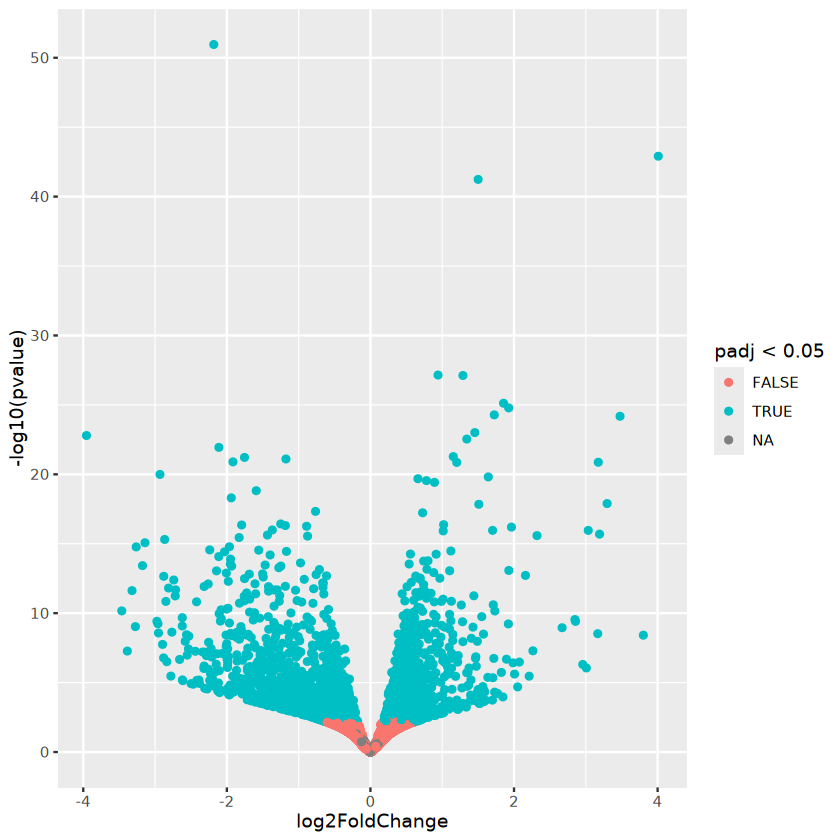

In [123]:
p <- gene_tdp43_mod %>%
  ggplot(
    aes(
      log2FoldChange,
      -log10(pvalue),
      color = padj < 0.05
    )
  ) +
  geom_point()

p

In [124]:
head((gene_tdp43_mod %>%
  filter(!is.na(log2FoldChange), !is.na(pvalue)) %>%
  arrange(desc(log2FoldChange))),n=10)

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000126759,616.469122,4.009213,0.2983307,1.234342e-43,1.259152e-39,4.197998,0.3030571
ENSG00000281348,14.951691,3.801449,0.8480985,3.842172e-09,3.098339e-07,5.688009,0.9655670
ENSG00000225066,54.663834,3.476643,0.3550429,6.613503e-25,1.499208e-21,3.723905,0.3613304
ENSG00000122641,157.014602,3.296659,0.4007492,1.275851e-18,9.640705e-16,3.606354,0.4094484
ENSG00000167414,54.081919,3.191356,0.4191206,2.027703e-16,1.009005e-13,3.526319,0.4289700
ENSG00000013364,162.817887,3.173735,0.3511135,1.353288e-21,1.492499e-18,3.404609,0.3566681
ENSG00000140678,74.069939,3.166080,0.6341480,2.997505e-09,2.569542e-07,3.987401,0.6722150
ENSG00000013588,143.480078,3.033770,0.3922881,1.097760e-16,5.742692e-14,3.318780,0.4001566
ENSG00000184459,9.822243,3.007277,0.9036665,8.846687e-07,3.655537e-05,4.647507,0.9454420


In [159]:
renvm_ISG_up

[1] "IFIH1"     "CXCL9"     "GTPBP1"    "DDX58"     "VAMP5"     "IRF1"     
  [7] "B2M"       "SPTLC2"    "IRF7"      "OASL"      "IFI44L"    "CCL2"     
 [13] "PDGFRL"    "MT1X"      "SOCS1"     "CCL4"      "HSH2D"     "GEM"      
 [19] "XAF1"      "HLA-G"     "SLFN5"     "IFI35"     "APOL2"     "USP18"    
 [25] "APOL1"     "FBXO6"     "JUNB"      "SLC25A28"  "HLA-E"     "MAB21L2"  
 [31] "C4orf33"   "WARS"      "IRF2"      "CCL5"      "TNFSF10"   "VEGFC"    
 [37] "IFITM2"    "TRIM21"    "TNFAIP6"   "IFIT1"     "PI4K2B"    "HK2"      
 [43] "IFITM3"    "MYD88"     "CCL8"      "DYNLT1"    "SP110"     "IFIT5"    
 [49] "ETV7"      "DTX3L"     "MT1H"      "NAPA"      "MAFB"      "NRN1"     
 [55] "CXCL10"    "C15orf48"  "NOD2"      "MT1G"      "EIF2AK2"   "DDIT4"    
 [61] "PMM2"      "HESX1"     "LAP3"      "LY6E"      "MT1F"      "ABTB2"    
 [67] "GTPBP2"    "TLR3"      "GMPR"      "BATF2"     "ISG15"     "TNFRSF10A"
 [73] "GCH1"      "GBP2"      "SERPINE1"  "DCP1A"     "SMAD3"     "EPSTI1"   
 [79] "MT1M"      "MAP3K14"   "AIM2"      "NFIL3"     "BTN3A3"    "BCL2L14"  
 [85] "PNRC1"     "KIAA0040"  "ENPP1"     "PML"       "PDK1"      "LGALS9"   
 [91] "CASP7"     "LGALS3"    "PARP12"    "HES4"      "OAS2"      "IFNGR1"   
 [97] "IFI44"     "TRIM5"     "SERPING1"  "MAFF"      "LGMN"      "UBE2L6"   
[103] "IMPA2"     "CEBPD"     "CYP1B1"    "SECTM1"    "PMAIP1"    "CXCL11"   
[109] "TMEM51"    "TNFSF13B"  "EXT1"      "ZBP1"      "HPSE"      "TYMP"     
[115] "BLVRA"     "MAX"       "TRIM14"    "FUT4"      "SCARB2"    "CCND3"    
[121] "TRIM38"    "MTHFD2L"   "CCR1"      "TBX3"      "SLC15A3"   "CD74"     
[127] "ISG20"     "MX1"       "DHX58"     "CHMP5"     "BCL3"      "LAMP3"    
[133] "EHD4"      "TDRD7"     "BAG1"      "DUSP5"     "HLA-C"     "AQP9"     
[139] "IL6ST"     "GBP4"      "GLRX"      "PHF11"     "MCOLN2"    "TLK2"     
[145] "IFI6"      "PPM1K"     "NCOA3"     "ATP10D"    "GBP5"      "SERPINB9" 
[151] "PTMA"      "BST2"      "AMPH"      "RARRES3"   "CX3CL1"    "STARD5"   
[157] "ADM"       "ETV6"      "IL1RN"     "FKBP5"     "UNC93B1"   "IFI27"    
[163] "GBP1"      "MCL1"      "SAMD4A"    "CLEC2B"    "IFIT3"     "IFI16"    
[169] "HLA-F"     "FNDC3B"    "NPAS2"     "LMO2"      "RNF19B"    "HEG1"     
[175] "PRKD2"     "CCNA1"     "PSMB9"     "LIPA"      "C1S"       "OPTN"     
[181] "NMI"       "ADAR"      "IDO1"      "DDX3X"     "TNFAIP3"   "TIMP1"    
[187] "IFIT2"     "JAK2"      "STAT2"     "ATF3"      "PSMB8"     "HERC6"    
[193] "MICB"      "GCA"       "GJA4"      "RBCK1"     "PIM3"      "GBP3"     
[199] "OGFR"      "SAMHD1"    "IL15"      "ELF1"      "PNPT1"     "RIPK2"    
[205] "SLC25A30"  "IL15RA"    "TRAFD1"    "CD38"      "CD274"     "SPSB1"    
[211] "PLSCR1"    "TRIM25"    "STAT1"     "MASTL"     "TMEM140"   "ZNF385B"  
[217] "TXNIP"     "RTP4"      "B4GALT5"   "TCF7L2"    "ACSL1"     "TAP1"     
[223] "RBM25"     "PLEKHA4"   "RSAD2"     "APOL6"     "RAB27A"    "IFITM1"   
[229] "MX2"       "DDX60"     "STAT3"     "RASGEF1B"  "PABPC4"    "OAS1"     
[235] "FLT1"      "OAS3"      "N4BP1"     "APOL3"     "BLZF1"

In [72]:
renvm_ISG_up

ERROR: Error: object 'renvm_ISG_up' not found


In [163]:
head(map_dedup,n=2)

,hgnc_symbol,ensembl_gene_id,entrezgene_id,gene_biotype
,<chr>,<chr>,<int>,<chr>
1,ABLIM3,ENSG00000173210,22885,protein_coding
2,ABTB2,ENSG00000166016,25841,protein_coding


In [164]:
map_dedup_mod <- map_dedup[map_dedup$hgnc_symbol %in% renvm_ISG_up, ]

In [165]:
dim(map_dedup_mod)

[1] 236   4

In [169]:
map_dedup_mod$ensembl_gene_id

[1] "ENSG00000166016" "ENSG00000151726" "ENSG00000160710" "ENSG00000148926"
  [5] "ENSG00000163568" "ENSG00000078053" "ENSG00000100342" "ENSG00000128335"
  [9] "ENSG00000128284" "ENSG00000221963" "ENSG00000103569" "ENSG00000162772"
 [13] "ENSG00000145246" "ENSG00000273686" "ENSG00000158470" "ENSG00000107262"
 [17] "ENSG00000168062" "ENSG00000281449" "ENSG00000069399" "ENSG00000106605"
 [21] "ENSG00000117475" "ENSG00000130303" "ENSG00000111801" "ENSG00000166920"
 [25] "ENSG00000182326" "ENSG00000151470" "ENSG00000165806" "ENSG00000108691"
 [29] "ENSG00000275824" "ENSG00000274233" "ENSG00000108700" "ENSG00000133101"
 [33] "ENSG00000112576" "ENSG00000163823" "ENSG00000120217" "ENSG00000004468"
 [37] "ENSG00000019582" "ENSG00000221869" "ENSG00000086065" "ENSG00000110852"
 [41] "ENSG00000006210" "ENSG00000169245" "ENSG00000169248" "ENSG00000138755"
 [45] "ENSG00000138061" "ENSG00000272886" "ENSG00000168209" "ENSG00000215301"
 [49] "ENSG00000137628" "ENSG00000108771" "ENSG00000163840" "ENSG00000138166"
 [53] "ENSG00000146425" "ENSG00000103966" "ENSG00000055332" "ENSG00000120690"
 [57] "ENSG00000197594" "ENSG00000133106" "ENSG00000139083" "ENSG00000010030"
 [61] "ENSG00000182197" "ENSG00000116663" "ENSG00000096060" "ENSG00000102755"
 [65] "ENSG00000075420" "ENSG00000196371" "ENSG00000117228" "ENSG00000162645"
 [69] "ENSG00000117226" "ENSG00000162654" "ENSG00000154451" "ENSG00000115271"
 [73] "ENSG00000131979" "ENSG00000164949" "ENSG00000187513" "ENSG00000173221"
 [77] "ENSG00000137198" "ENSG00000100226" "ENSG00000172432" "ENSG00000173706"
 [81] "ENSG00000138642" "ENSG00000188290" "ENSG00000163666" "ENSG00000159399"
 [85] "ENSG00000206435" "ENSG00000230254" "ENSG00000235220" "ENSG00000276051"
 [89] "ENSG00000173083" "ENSG00000196684" "ENSG00000131203" "ENSG00000163565"
 [93] "ENSG00000275214" "ENSG00000068079" "ENSG00000137965" "ENSG00000137959"
 [97] "ENSG00000126709" "ENSG00000115267" "ENSG00000185745" "ENSG00000119922"
[101] "ENSG00000119917" "ENSG00000152778" "ENSG00000185885" "ENSG00000185201"
[105] "ENSG00000142089" "ENSG00000027697" "ENSG00000164136" "ENSG00000134470"
[109] "ENSG00000136689" "ENSG00000134352" "ENSG00000141401" "ENSG00000125347"
[113] "ENSG00000168310" "ENSG00000276561" "ENSG00000187608" "ENSG00000172183"
[117] "ENSG00000096968" "ENSG00000171223" "ENSG00000235750" "ENSG00000078081"
[121] "ENSG00000002549" "ENSG00000131981" "ENSG00000168961" "ENSG00000100600"
[125] "ENSG00000107798" "ENSG00000135363" "ENSG00000278032" "ENSG00000181541"
[129] "ENSG00000204103" "ENSG00000185022" "ENSG00000006062" "ENSG00000120539"
[133] "ENSG00000125952" "ENSG00000143384" "ENSG00000153898" "ENSG00000204516"
[137] "ENSG00000198417" "ENSG00000125144" "ENSG00000205358" "ENSG00000205364"
[141] "ENSG00000187193" "ENSG00000163738" "ENSG00000157601" "ENSG00000183486"
[145] "ENSG00000172936" "ENSG00000102921" "ENSG00000105402" "ENSG00000124151"
[149] "ENSG00000165030" "ENSG00000123609" "ENSG00000167207" "ENSG00000170485"
[153] "ENSG00000124785" "ENSG00000089127" "ENSG00000111335" "ENSG00000111331"
[157] "ENSG00000135114" "ENSG00000060491" "ENSG00000123240" "ENSG00000090621"
[161] "ENSG00000059378" "ENSG00000104213" "ENSG00000152256" "ENSG00000136147"
[165] "ENSG00000038210" "ENSG00000198355" "ENSG00000105559" "ENSG00000188313"
[169] "ENSG00000141682" "ENSG00000140464" "ENSG00000140650" "ENSG00000138035"
[173] "ENSG00000146278" "ENSG00000163644" "ENSG00000105287" "ENSG00000230669"
[177] "ENSG00000243958" "ENSG00000187514" "ENSG00000069974" "ENSG00000138670"
[181] "ENSG00000125826" "ENSG00000119707" "ENSG00000104312" "ENSG00000116514"
[185] "ENSG00000134321" "ENSG00000291555" "ENSG00000020577" "ENSG00000101347"
[189] "ENSG00000138760" "ENSG00000141574" "ENSG00000170542" "ENSG00000106366"
[193] "ENSG00000149131" "ENSG00000110446" "ENSG00000155287" "ENSG00000174032"
[197] "ENSG00000166750" "ENSG00000166949" "ENSG00000185338" "ENSG00000135899"
[201] "ENSG00000171621" "ENSG00000100596" "ENSG00000172345" "ENSG00000115415"
[205] "ENSG00000170581" 

In [170]:
gene_tdp43_mod[gene_tdp43_mod$gene_id %in% map_dedup_mod$ensembl_gene_id,]

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000002549,274.822717,1.43984247,0.21862273,5.602599e-12,9.293027e-10,1.50155069,0.2179507
ENSG00000004468,18.140734,0.65055818,0.77929312,5.821405e-03,4.841757e-02,2.25413758,0.8174051
ENSG00000006062,102.761764,0.14020908,0.19313681,2.211073e-01,5.212053e-01,0.35749802,0.2921717
ENSG00000006210,914.209352,-0.19805593,0.11140950,3.329884e-02,1.646142e-01,-0.25963510,0.1219825
ENSG00000010030,2.284189,-0.02540827,0.32520737,7.436435e-01,NA,-0.43649513,1.3347160
ENSG00000019582,95.335331,0.02968257,0.22248614,7.669861e-01,9.162347e-01,0.14491643,0.4890547
ENSG00000020577,429.852181,-0.57513207,0.22116920,1.027526e-04,1.994632e-03,-0.77324035,0.1990836
ENSG00000025708,10.169469,-0.06321637,0.25060630,5.171671e-01,7.881709e-01,-0.39119350,0.6039562
ENSG00000027697,162.372584,-0.08973422,0.16294718,4.141544e-01,7.122632e-01,-0.18968676,0.2322872


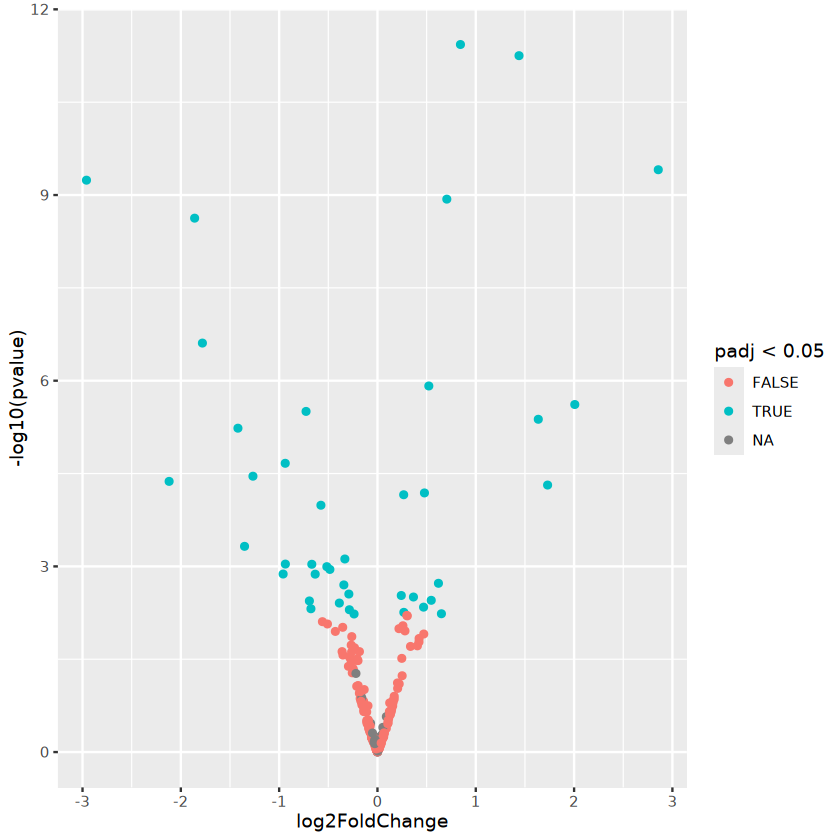

In [171]:
p <- gene_tdp43_mod[gene_tdp43_mod$gene_id %in% map_dedup_mod$ensembl_gene_id,] %>%
  ggplot(
    aes(
      log2FoldChange,
      -log10(pvalue),
      color = padj < 0.05
    )
  ) +
  geom_point()

p

In [172]:
gene_tdp43_mod[gene_tdp43_mod$gene_id %in% map_dedup_mod$ensembl_gene_id,]

gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,log2FoldChange_MLE,lfcSE_MLE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000002549,274.822717,1.43984247,0.21862273,5.602599e-12,9.293027e-10,1.50155069,0.2179507
ENSG00000004468,18.140734,0.65055818,0.77929312,5.821405e-03,4.841757e-02,2.25413758,0.8174051
ENSG00000006062,102.761764,0.14020908,0.19313681,2.211073e-01,5.212053e-01,0.35749802,0.2921717
ENSG00000006210,914.209352,-0.19805593,0.11140950,3.329884e-02,1.646142e-01,-0.25963510,0.1219825
ENSG00000010030,2.284189,-0.02540827,0.32520737,7.436435e-01,NA,-0.43649513,1.3347160
ENSG00000019582,95.335331,0.02968257,0.22248614,7.669861e-01,9.162347e-01,0.14491643,0.4890547
ENSG00000020577,429.852181,-0.57513207,0.22116920,1.027526e-04,1.994632e-03,-0.77324035,0.1990836
ENSG00000025708,10.169469,-0.06321637,0.25060630,5.171671e-01,7.881709e-01,-0.39119350,0.6039562
ENSG00000027697,162.372584,-0.08973422,0.16294718,4.141544e-01,7.122632e-01,-0.18968676,0.2322872


 ## comments from Clemens
### scaling (mean 0, SD 1) ISG expression across samples by gene and then compute the mean: https://github.com/labsyspharm/ad-personalized/blob/d4123bea613c9240356229e2f26bdfeccde1479e/revision_plots.R#L235

In [73]:
df_all_counts <- list(
  normalized = counts(des2, normalized = TRUE),
  raw = counts(des2, normalized = FALSE)
)

In [74]:
type(df_all_counts)

[1] "list"

In [75]:
df_norm <- counts(des2, normalized = TRUE)

In [76]:
type(df_norm)

[1] "double"

In [77]:
df_gen_log <- log10(df_norm+1)

In [78]:
type(df_gen_log)

[1] "double"

In [79]:
glimpse(df_gen_log)

 num [1:35278, 1:14] 1.725 0.297 2.774 2.471 2.349 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:35278] "ENSG00000000003" "ENSG00000000005" "ENSG00000000419" "ENSG00000000457" ...
  ..$ : chr [1:14] "SRR8571937" "SRR8571938" "SRR8571939" "SRR8571940" ...


In [80]:
df_gen_log_scaled <- t(scale(t(df_gen_log)))

In [81]:
glimpse(df_gen_log_scaled)

 num [1:35278, 1:14] 0.957 -0.272 -1.216 -0.6 -0.134 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:35278] "ENSG00000000003" "ENSG00000000005" "ENSG00000000419" "ENSG00000000457" ...
  ..$ : chr [1:14] "SRR8571937" "SRR8571938" "SRR8571939" "SRR8571940" ...
 - attr(*, "scaled:center")= Named num [1:35278] 1.389 0.382 2.876 2.58 2.366 ...
  ..- attr(*, "names")= chr [1:35278] "ENSG00000000003" "ENSG00000000005" "ENSG00000000419" "ENSG00000000457" ...
 - attr(*, "scaled:scale")= Named num [1:35278] 0.3506 0.3121 0.0832 0.1808 0.1305 ...
  ..- attr(*, "names")= chr [1:35278] "ENSG00000000003" "ENSG00000000005" "ENSG00000000419" "ENSG00000000457" ...


In [ ]:
## gene_tdp43_mod[gene_tdp43_mod$gene_id %in% map_dedup_mod$ensembl_gene_id,]